# Brain Tumor Classification

With dataset merge (training + testing) before preprocessing. Hence,

`Acquire -> Merge data from folders (Train & Test) -> train_test_split() merged data -> Preprocess -> Extract -> Classify -> Evaluation -> XAI`

## TODO(s)
- scale/normalize svm features
- optimize feature extractions time
- fix cnn accuracy

## Preparation

### System Check

In [21]:
# Software check (OS)
!uname -a

# Hardware check (CPU, GPU, RAM)
!inxi

Linux xt 6.17.0-19-generic #19~24.04.2-Ubuntu SMP PREEMPT_DYNAMIC Fri Mar  6 23:08:46 UTC 2 x86_64 x86_64 x86_64 GNU/Linux
CPU: 6-core AMD Ryzen 5 7640HS w/ Radeon 760M Graphics (-MT MCP-)
speed/min/max: 2109/410/5018 MHz Kernel: 6.17.0-19-generic x86_64 Up: 2m
Mem: 7.66/14.81 GiB (51.7%) Storage: 1.38 TiB (3.0% used) Procs: 433
Shell: python inxi: 3.3.34


### Library Imports


In [22]:
import os
from glob import glob
from zipfile import ZipFile

import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

import time

from skimage.feature import local_binary_pattern

# from sklearn.preprocessing import scale, normalize
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier 
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.svm import SVC

import keras
from keras import layers

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from lime import lime_image

### Global Variable(s)

In [23]:
# Image size for resize process of preprocessing step
IMAGE_SIZE = 128
CNN_IMAGE_SIZE = 224

# Image and histogram preview index
PRVW_IDX = 0

# List of utilized feature extraction methods and their parameters
FEATURES = ["lbp-lib", "lbp", 
            "nlbp1", "nlbp2", "nlbp3", "nlbp4", 
            "albp0", "albp45", "albp90", "albp135", 
            "mblbp2", "mblbp3", "mblbp4", 
            "semblbp2", "semblbp3", "semblbp4"]

## Dataset Acquisition


In [24]:
data_path = "./data/"
dataset_file = data_path + "brain-sartaj.zip"

# Extract zipped dataset file
zipfile = ZipFile(dataset_file)
zipfile.extractall(data_path)
zipfile.close()

print(os.listdir(data_path))

['Training', 'Testing', 'brain-sartaj.zip']


### Train & Test Merge

In [25]:
train_path = os.path.join(data_path, "Training")
test_path = os.path.join(data_path, "Testing")

# List of dataset classes/labels
classes = os.listdir(train_path)

print("Classes:", classes)

Classes: ['meningioma_tumor', 'glioma_tumor', 'pituitary_tumor', 'no_tumor']


In [26]:
# Data and labels from merged Training and Testing folders
X, y = [], []

for idx, label in enumerate(classes):
    # Input Training folder image data and labels to merged lists
    train_images = glob(os.path.join(train_path, label, "*.jpg"))
    for img_raw in train_images:
        img = cv.imread(img_raw)
        X.append(img)
        y.append(idx)
    
    # Input Testing folder image data and labels to merged lists
    test_images = glob(os.path.join(test_path, label, "*.jpg"))
    for img_raw in test_images:
        img = cv.imread(img_raw)
        X.append(img)
        y.append(idx)

print("X\ty")
print(f"{len(X)}\t{len(y)}")

X	y
3264	3264


### Train & Test Split

In [27]:
# Split data into train and test set with the ratio of 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("X_train\ty_train\t")
print(f"{len(X_train)}\t{len(y_train)}\n")
print("X_test\ty_test\t")
print(f"{len(X_test)}\t{len(y_test)}\t")

X_train	y_train	
2611	2611

X_test	y_test	
653	653	


## Classical Machine Learning

### ML - Preprocessing

In [28]:
# Data preprocessing function for machine learning classifiers
def preprocess_ml(images):
    preprocessed = []
    for img in images:
        # Resize image into same resolutions
        img_resized = cv.resize(img, (IMAGE_SIZE, IMAGE_SIZE))

        # Convert image from BGR (3-channels) to grayscale (1-channel)
        img_grayscaled = cv.cvtColor(img_resized, cv.COLOR_BGR2GRAY)
        
        preprocessed.append(img_grayscaled)
    return preprocessed

In [29]:
# Preprocess dataset for machine learning feature extractions
X_train_prep = preprocess_ml(X_train)
X_test_prep = preprocess_ml(X_test)

print("X_train_prep\ty_train")
print(f"{len(X_train_prep)}\t\t{len(y_train)}\n")
print("X_test_prep\ty_test")
print(f"{len(X_test_prep)}\t\t{len(y_test)}")

X_train_prep	y_train
2611		2611

X_test_prep	y_test
653		653


Preview prepared dataset

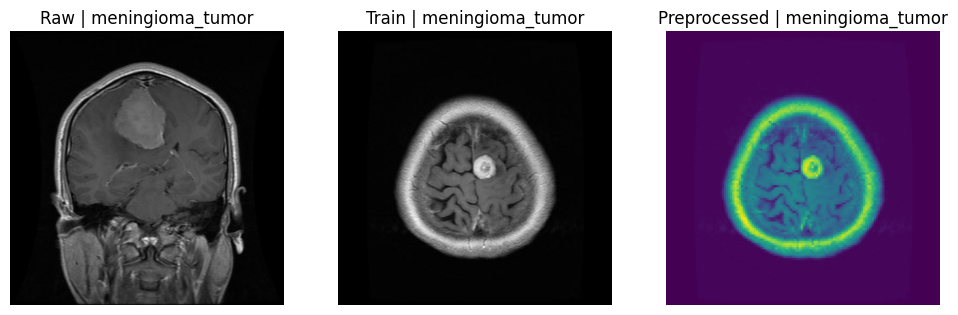

In [30]:
plt.figure(figsize=(12,4))

# Raw (merged) dataset
plt.subplot(1, 3, 1)
plt.title(f"Raw | {classes[y[PRVW_IDX]]}")
plt.axis('off')
plt.imshow(X[PRVW_IDX])

# Train dataset
plt.subplot(1, 3, 2)
plt.title(f"Train | {classes[y_train[PRVW_IDX]]}")
plt.axis('off')
plt.imshow(X_train[PRVW_IDX])

# Preprocessed train dataset
plt.subplot(1,3,3)
plt.title(f"Preprocessed | {classes[y_train[PRVW_IDX]]}")
plt.axis('off')
plt.imshow(X_train_prep[PRVW_IDX])

plt.show()

### ML - Feature Extraction

In [ ]:
# Neighboring pixels' coordinates of the center pixel
P_COORDS = [(-1, -1), (-1, 0), (-1, 1), # top (pixel positions from the center)
            ( 0,  1),                   # right
            ( 1,  1), ( 1, 0), (1, -1), # bottom
            ( 0, -1)]                   # left

In [ ]:
def get_decimal(binary, uniform=True):
    transition = 0
    decimal = 0

    # Assign each binary digit to its decimal weight
    for i in range(8):
        # Count transitions by comparing current bit with its next bit
        transition += binary[i] != binary[(i+1) % 8]
        # Convert every bit into its decimal value
        decimal = decimal * 2 + binary[i]

    # Uniform pattern filtering for classical LBP
    if(uniform): return decimal if(transition <= 2) else 256

    return decimal

# Get histogram representation of uniform binary patterns from an image
def get_histogram(img, non=0, lib=False):
    histogram, _ = np.histogram(a=img, bins=[x for x in range(257)])
    uniform_histogram = []

    if(non > 0): 
        uniform_histogram = np.delete(histogram, np.where(histogram == 0))
        uniform_histogram = np.append(uniform_histogram, non)
        return uniform_histogram
    
    if(lib):
        histogram = np.delete(histogram, np.where(histogram == 0))

    return histogram

In [33]:
# tes = X_test_prep[100]
# teslbp, teslbphist = get_lbp(tes)
# teslbplib = local_binary_pattern(tes, R=1, P=8, method="nri_uniform")
# teslbplibhist = get_histogram(teslbplib, lib=True)
# tesnlbp, tesnlbphist = get_nlbp(tes, 1)
# tesalbp, tesalbphist = get_albp(tes, 135)
# tesmblbp, tesmblbphist = get_mblbp(tes, 4)
# tessemblbp, tessemblbphist = get_mblbp(tes, 4, v=15)

# print("LBP", "LIB", "n", "a", "MB", "SE", sep="\t")
# print(len(teslbphist), len(teslbplibhist), len(tesnlbphist), len(tesalbphist), len(tesmblbphist), len(tessemblbphist), sep="\t")

# plt.figure(figsize=(10,20))

# plt.subplot(6,2,1)
# plt.title("Scratch LBP")
# plt.bar(np.arange(len(teslbphist[1:])), teslbphist[1:])
# plt.subplot(6,2,2)
# plt.imshow(teslbp)

# plt.subplot(6,2,3)
# plt.title("Library LBP")
# plt.bar(np.arange(len(teslbplibhist[1:])), teslbplibhist[1:])
# plt.subplot(6,2,4)
# plt.imshow(teslbplib)

# plt.subplot(6,2,5)
# plt.title("nLBP")
# plt.bar(np.arange(len(tesnlbphist[1:])), tesnlbphist[1:])
# plt.subplot(6,2,6)
# plt.imshow(tesnlbp)

# plt.subplot(6,2,7)
# plt.title("aLBP")
# plt.bar(np.arange(len(tesalbphist[1:])), tesalbphist[1:])
# plt.subplot(6,2,8)
# plt.imshow(tesalbp)

# plt.subplot(6,2,9)
# plt.title("MB-LBP")
# plt.bar(np.arange(len(tesmblbphist[1:])), tesmblbphist[1:])
# plt.subplot(6,2,10)
# plt.imshow(tesmblbp)

# plt.subplot(6,2,11)
# plt.title("SEMB-LBP")
# plt.bar(np.arange(len(tessemblbphist[1:])), tessemblbphist[1:])
# plt.subplot(6,2,12)
# plt.imshow(tessemblbp)
# plt.show()

#### Classic LBP

In [34]:
def get_lbp(img, uniform=True):
    height, width = img.shape
    # Add padding to image edges with the value of 0
    img_pad = np.pad(img, pad_width=1, mode="constant", constant_values=0)
    img_lbp = np.zeros((height, width), np.uint8)
    non_uniform = 0

    for i in range(height):
        for j in range(width):
            # Center pixel on padded image
            c_i, c_j = i+1, j+1
            c = img_pad[c_i, c_j]

            # Each center pixel's binary representation
            c_bin = []

            for p_coord in P_COORDS:
                # Neighboring pixels of center pixel
                p = img_pad[c_i + p_coord[0], c_j + p_coord[1]]

                # Threshold and append bit value to pixel representation
                c_bin.append(1 if(p > c) else 0)

            # Assign uniform pattern pixels' decimal representation value to feature vector
            decimal = get_decimal(c_bin, uniform=uniform)
            if(decimal == 256): non_uniform += 1
            else: img_lbp[i][j] = decimal

    hist_lbp = get_histogram(img_lbp, non_uniform)

    return img_lbp, hist_lbp

#### nLBP


In [35]:
def get_nlbp(img, d):
    height, width = img.shape
    # Add padding to image edges with the value of 0
    img_pad = np.pad(img, pad_width=1, mode="constant", constant_values=0)
    img_nlbp = np.zeros((height, width), np.uint8)
    non_uniform = 0

    for i in range(height):
        for j in range(width):
            # Center pixel on padded image
            c_i, c_j = i+1, j+1

            # Each center pixel's binary representation
            c_bin = []

            # Each neighboring pixel operations
            for k in range(8):
                # First neighboring pixel to compare
                p_a = img_pad[c_i + P_COORDS[k][0], c_j + P_COORDS[k][1]]
                
                # Second neighboring pixel to compare
                p_b_idx = (k+d) % 8
                p_b = img_pad[c_i + P_COORDS[p_b_idx][0], c_j + P_COORDS[p_b_idx][1]]

                # Threshold and append bit value to pixel representation
                c_bin.append(1 if(p_a > p_b) else 0)

            # Assign uniform pattern pixels' decimal representation value to feature vector
            decimal = get_decimal(c_bin, uniform=False)
            if(decimal == 256): non_uniform += 1
            else: img_nlbp[i][j] = decimal

    hist_nlbp = get_histogram(img_nlbp, non_uniform)

    return img_nlbp, hist_nlbp

#### αLBP


In [ ]:
def get_albp(img, alpha, neighbors=4):
    height, width = img.shape
    # Add 4 pixels of padding to image edges with the value of 0
    img_pad = np.pad(img, pad_width=neighbors, mode="constant", constant_values=0)
    img_albp = np.zeros((height, width), np.uint8)
    non_uniform = 0

    # Neighboring pixels' coordinate candidates 
    # based on the chosen alpha parameter
    p_coords_list = {
        0  : [( 0, 4), ( 0, 3), ( 0, 2), ( 0, 1), ( 0,-1), ( 0,-2), ( 0,-3), ( 0,-4)],
        45 : [(-4, 4), (-3, 3), (-2, 2), (-1, 1), ( 1,-1), ( 2,-2), ( 3,-3), ( 4,-4)],
        90 : [(-4, 0), (-3, 0), (-2, 0), (-1, 0), ( 1, 0), ( 2, 0), ( 3, 0), ( 4, 0)],
        135: [(-4,-4), (-3,-3), (-2,-2), (-1,-1), ( 1, 1), ( 2, 2), ( 3, 3), ( 4, 4)],
    }

    # Handle alpha parameter input outside scope
    if(alpha % 360 not in p_coords_list.keys()):
        return print("Incorrect alpha parameter value")

    for i in range(height):
        for j in range(width):
            # Center pixel on padded image
            c_i, c_j = i+neighbors, j+neighbors
            c = img_pad[c_i][c_j]
            
            # Chosen neighboring pixels based on the alpha parameter
            p_coords = p_coords_list[alpha]

            # Each pixel's binary representation
            c_bin = []

            for p in p_coords:
                # Coordinates of the neighboring pixels based on their center
                p_i_crd = c_i + p[0]
                p_j_crd = c_j + p[1]
                
                # Find neighboring pixel of the center pixel
                p = img_pad[p_i_crd, p_j_crd]

                # Threshold and append binary value to pixel representation
                c_bin.append(1 if p > c else 0)

            # Assign each pixels' decimal representation value to feature vector
            decimal = get_decimal(c_bin, uniform=False)
            if(decimal == 256): non_uniform += 1
            else: img_albp[i][j] = decimal

    hist_albp = get_histogram(img_albp, non_uniform)

    return img_albp, hist_albp

#### MB-LBP (and SEMB-LBP)

In [37]:
def get_integral_image(img, height, width):
    img_integral = np.zeros((height, width), int)
    img_integral_pad = np.pad(img_integral, pad_width=1, mode="constant", constant_values=0)
    
    for i in range(height):
        for j in range(width):
            # Get the pixel integral image value by adding its pixel intensity value 
            # with its above and left side integral image pixel value
            # then substracting it with overlapping values (top-left side) 
            img_integral_pad[i][j] = img[i][j] + img_integral_pad[i-1][j] + img_integral_pad[i][j-1] - img_integral_pad[i-1][j-1]

    # Return image integral result with removed zero paddings
    return img_integral_pad[:-2,:-2]

def get_mblbp(img, region_size, v=0):
    height, width = img.shape

    # Rounded (ceiling division) size values from base image to get the region image size
    region_height = -(-height // region_size)
    region_width = -(-width // region_size)

    img_integral = get_integral_image(img, height, width)
    img_region = np.zeros((region_height, region_width), int)
    img_pad = np.pad(img_integral, pad_width=region_size, mode="constant", constant_values=0)

    for i in range(region_height):
        for j in range(region_width):
            # Integral image variables
            # Top-Left
            a = img_pad[i*region_size-1, j*region_size-1] if(i*region_size-1>0 and j*region_size-1>0) else 0
            # Top-Right
            b = img_pad[i*region_size-1, j*region_size+region_size-1] if(i*region_size-1>0 and j*region_size+region_size-1>0) else 0
            # Bottom-Left
            c = img_pad[i*region_size+region_size-1, j*region_size-1] if(i*region_size+region_size-1>0 and j*region_size-1>0) else 0
            # Bottom-Right
            d = img_pad[i*region_size+region_size-1, j*region_size+region_size-1]
            
            # Region's sum and mean value using integral image formula
            region_sum = d - b - c + a
            img_region[i][j] = region_sum / (region_size*region_size)

    # LBP feature of image region blocks
    # img_mblbp = local_binary_pattern(img_region, P=8, R=1) if is_lib else 
    
    img_mblbp, hist_mblbp = get_lbp(img_region, uniform=False)

    # SEMB-LBP
    if(v > 0): hist_mblbp = get_semblbp_histogram(img_mblbp, v)

    return img_mblbp, hist_mblbp

def get_semblbp_histogram(img, v=63):
    # Top n features
    n = 63
    # Image region histogram from MB-LBP features
    semb_hist = get_histogram(img)
    # Descendingly sorted indices of mostly appeared features in image histogram
    semb_sorted_idx = np.argsort(semb_hist)[::-1]
    # SEMB-LBP image features
    # Keep the n mostly appeared feature values,
    # Set the rest (>=n+1)th mostly appeared values to v 
    semb_sorted = np.array([(semb_hist[i]) if i in semb_sorted_idx[:n] else v for i in range(256)])

    return semb_sorted

#### Feature Extraction Process

In [38]:
# Feature extraction function for all methods
def get_features(images, method, param=None, v=None):
    print(f"{len(images)} images > Method: {method}\tParam: {param}\t", end="")
    
    # Begin feature extraction time counting
    start = time.perf_counter()
    
    features, histograms = [], []

    for image in images:
        img_feature, img_histogram = [], []

        # - - - - - - - - Features - - - - - - - -
        match method:
            # Local binary pattern using library from scikit learn
            case "lbp-lib":
                img_feature = local_binary_pattern(image, P=8, R=1, method="nri_uniform")
                img_histogram = get_histogram(img_feature)
            # Local binary pattern from scratch
            case "lbp":
                img_feature, img_histogram = get_lbp(image)
            case "nlbp":
                img_feature, img_histogram = get_nlbp(image, param)
            case "albp":
                img_feature, img_histogram = get_albp(image, param)
            # MB-LBP 
            case "mblbp":
                img_feature, img_histogram = get_mblbp(image, param)
            # SEMB-LBP
            case _:
                img_feature, img_histogram = get_mblbp(image, param, v)

        features.append(img_feature)
        histograms.append(img_histogram)
        
    # End feature extraction time counting
    end = time.perf_counter()

    print(f"> Completed in {end - start}s.")

    return features, histograms

In [39]:
print(" "*25, "Extracting Features: Training Data", " "*25)

X_train_lbplib, X_train_lbplib_hist = get_features(X_train_prep, "lbp-lib")
X_train_lbp, X_train_lbp_hist = get_features(X_train_prep, "lbp")

X_train_nlbp1, X_train_nlbp1_hist = get_features(X_train_prep, "nlbp", 1)
X_train_nlbp2, X_train_nlbp2_hist = get_features(X_train_prep, "nlbp", 2)
X_train_nlbp3, X_train_nlbp3_hist = get_features(X_train_prep, "nlbp", 3)
X_train_nlbp4, X_train_nlbp4_hist = get_features(X_train_prep, "nlbp", 4)

X_train_albp0, X_train_albp0_hist = get_features(X_train_prep, "albp", 0)
X_train_albp45, X_train_albp45_hist = get_features(X_train_prep, "albp", 45)
X_train_albp90, X_train_albp90_hist = get_features(X_train_prep, "albp", 90)
X_train_albp135, X_train_albp135_hist = get_features(X_train_prep, "albp", 135)

X_train_mblbp2, X_train_mblbp2_hist = get_features(X_train_prep, "mblbp", 2)
X_train_mblbp3, X_train_mblbp3_hist = get_features(X_train_prep, "mblbp", 3)
X_train_mblbp4, X_train_mblbp4_hist = get_features(X_train_prep, "mblbp", 4)

X_train_semblbp2, X_train_semblbp2_hist = get_features(X_train_prep, "semb", 2, 63)
X_train_semblbp3, X_train_semblbp3_hist = get_features(X_train_prep, "semb", 3, 31)
X_train_semblbp4, X_train_semblbp4_hist = get_features(X_train_prep, "semb", 4, 15)

                          Extracting Features: Training Data                          
2611 images > Method: lbp-lib	Param: None	> Completed in 5.72870445800001s.
2611 images > Method: lbp	Param: None	> Completed in 73.667570711s.
2611 images > Method: nlbp	Param: 1	> Completed in 110.489643247s.
2611 images > Method: nlbp	Param: 2	> Completed in 111.223481725s.
2611 images > Method: nlbp	Param: 3	> Completed in 110.48605954799996s.
2611 images > Method: nlbp	Param: 4	> Completed in 109.8121326559999s.
2611 images > Method: albp	Param: 0	> Completed in 76.45258196199995s.
2611 images > Method: albp	Param: 45	> Completed in 76.23336367599995s.
2611 images > Method: albp	Param: 90	> Completed in 80.74003439600006s.
2611 images > Method: albp	Param: 135	> Completed in 76.813699638s.
2611 images > Method: mblbp	Param: 2	> Completed in 57.00118541900008s.
2611 images > Method: mblbp	Param: 3	> Completed in 41.47240996000005s.
2611 images > Method: mblbp	Param: 4	> Completed in 35.9709132170

In [44]:
X_train_feats = [X_train_lbplib, X_train_lbp,
                 X_train_nlbp1, X_train_nlbp2, X_train_nlbp3, X_train_nlbp4,
                 X_train_albp0, X_train_albp45, X_train_albp90, X_train_albp135, 
                 X_train_mblbp2, X_train_mblbp3, X_train_mblbp4,
                 X_train_semblbp2, X_train_semblbp3, X_train_semblbp4]
X_train_hists = [X_train_lbplib_hist, X_train_lbp_hist,
                 X_train_nlbp1_hist, X_train_nlbp2_hist, X_train_nlbp3_hist, X_train_nlbp4_hist, 
                 X_train_albp0_hist, X_train_albp45_hist, X_train_albp90_hist, X_train_albp135_hist, 
                 X_train_mblbp2_hist, X_train_mblbp3_hist, X_train_mblbp4_hist,
                 X_train_semblbp2_hist, X_train_semblbp3_hist, X_train_semblbp4_hist]

#### Feature Extraction Data

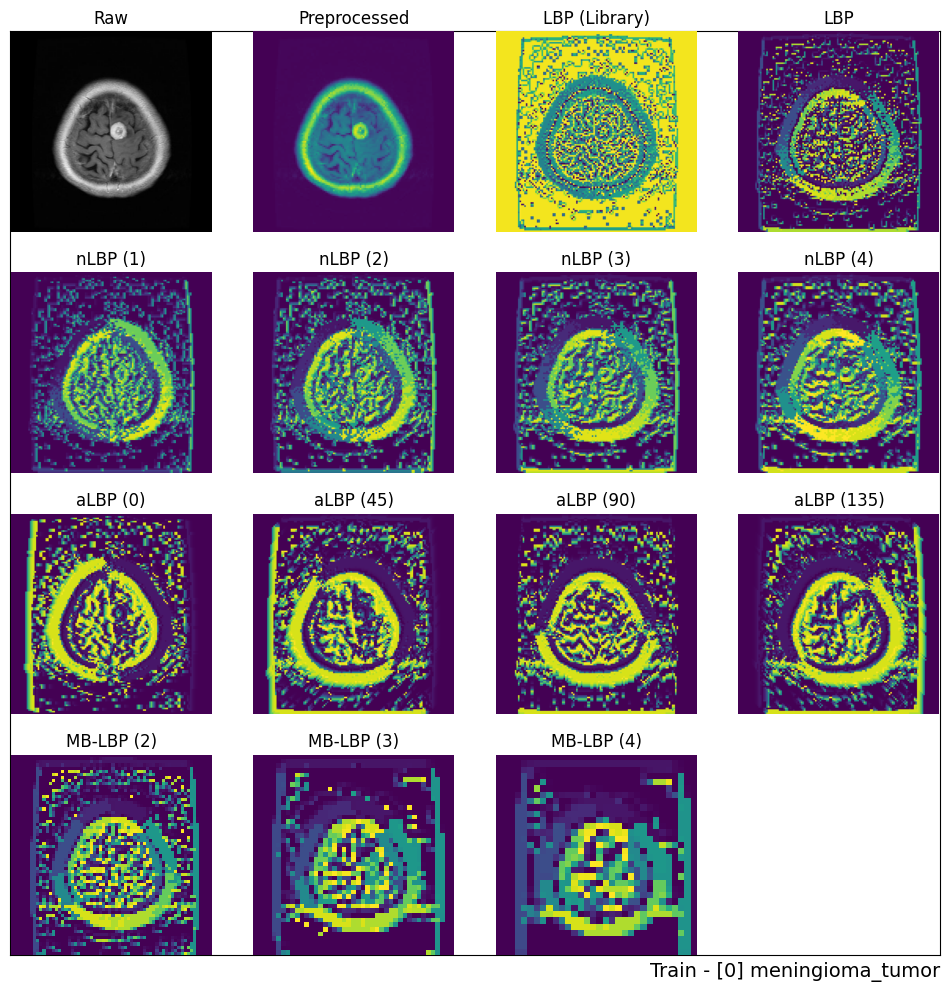

In [45]:
plt.figure(figsize=(12,12))
plt.xlabel(f"Train - [{PRVW_IDX}] {classes[y_train[PRVW_IDX]]}", fontsize=14, loc="right")
plt.yticks([])
plt.xticks([])

def get_image_preview(title, data, idx):
    plt.subplot(4, 4, idx)
    plt.axis("off")
    plt.title(f"{title}")
    plt.imshow(data[PRVW_IDX])

get_image_preview("Raw", X_train, 1)
get_image_preview("Preprocessed", X_train_prep, 2)
get_image_preview("LBP (Library)", X_train_lbplib, 3)
get_image_preview("LBP", X_train_lbp, 4)
get_image_preview("nLBP (1)", X_train_nlbp1, 5)
get_image_preview("nLBP (2)", X_train_nlbp2, 6)
get_image_preview("nLBP (3)", X_train_nlbp3, 7)
get_image_preview("nLBP (4)", X_train_nlbp4, 8)
get_image_preview("aLBP (0)", X_train_albp0, 9)
get_image_preview("aLBP (45)", X_train_albp45, 10)
get_image_preview("aLBP (90)", X_train_albp90, 11)
get_image_preview("aLBP (135)", X_train_albp135, 12)
get_image_preview("MB-LBP (2)", X_train_mblbp2, 13)
get_image_preview("MB-LBP (3)", X_train_mblbp3, 14)
get_image_preview("MB-LBP (4)", X_train_mblbp4, 15)
# get_image("SEMB-LBP (2)", X_train_semblbp2, 17)
# get_image("SEMB-LBP (3)", X_train_semblbp3, 18)
# get_image("SEMB-LBP (4)", X_train_semblbp4, 19)

plt.show()

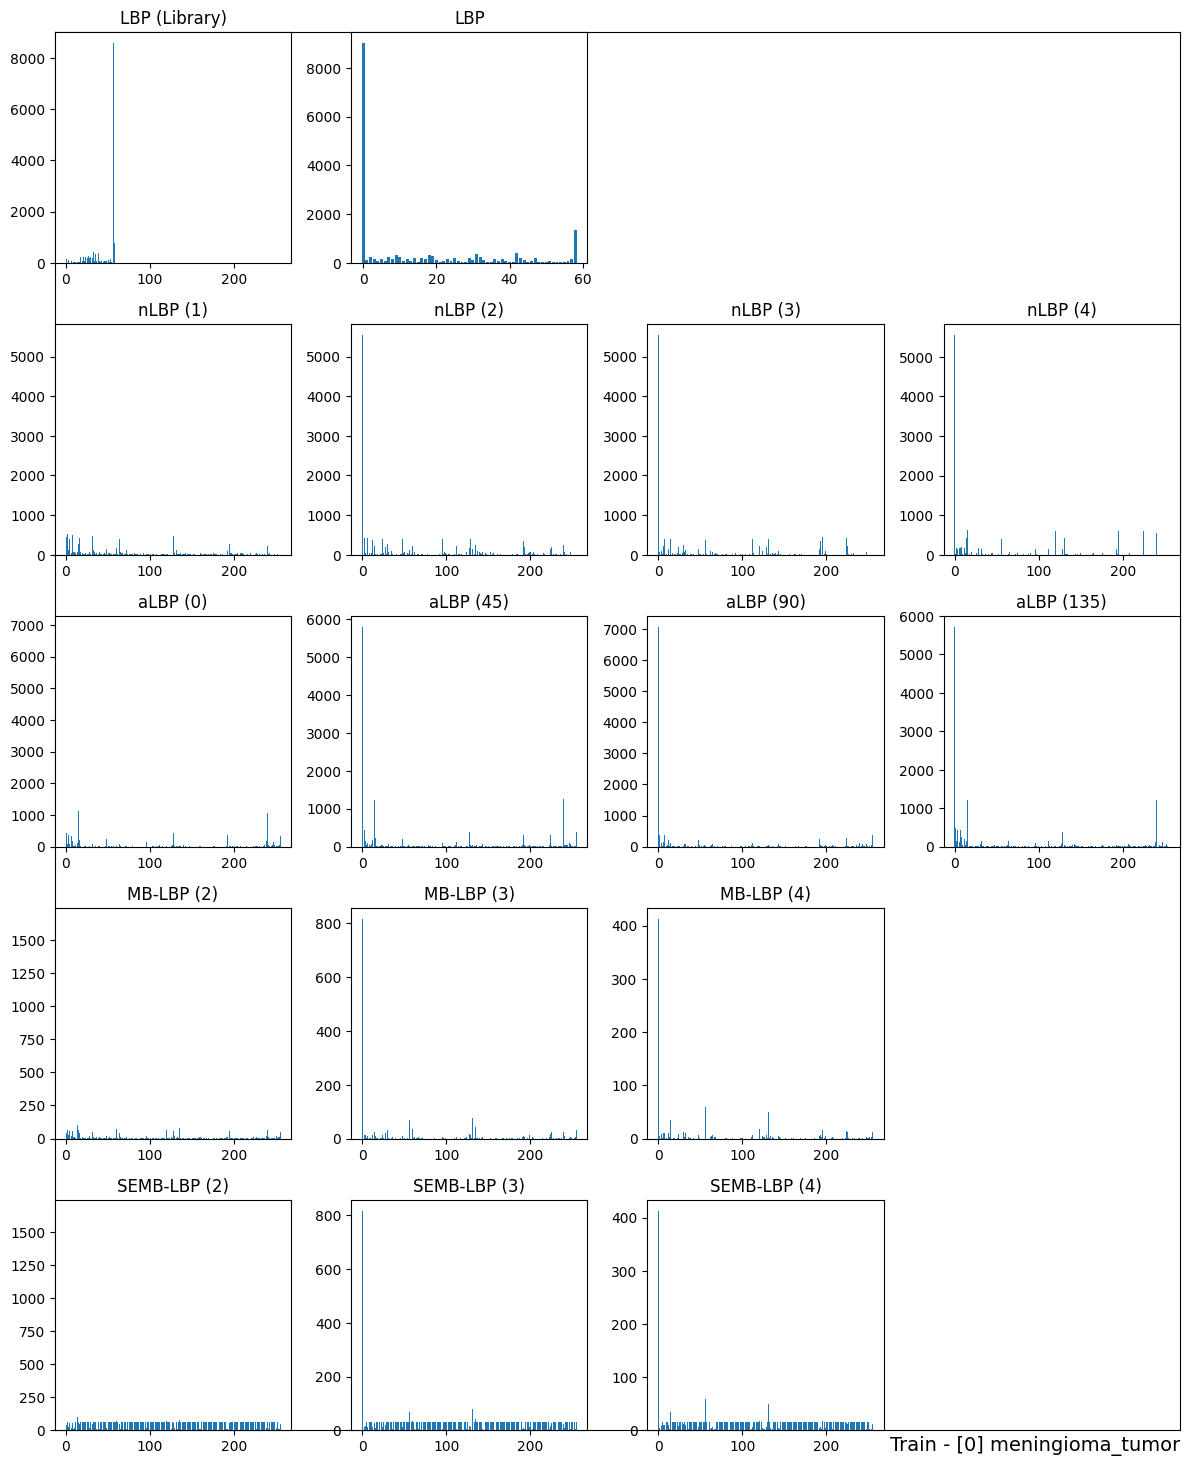

In [86]:
plt.figure(figsize=(12,15))
plt.xlabel(f"Train - [{PRVW_IDX}] {classes[y_train[PRVW_IDX]]}", fontsize=14, loc="right")
plt.yticks([])
plt.xticks([])

def get_histogram_preview(title, data, idx):
    plt.subplot(5, 4, idx)
    plt.title(f"{title}")
    plt.tight_layout()
    plt.bar(np.arange(len(data[PRVW_IDX])), data[PRVW_IDX])

# get_histogram_preview("Raw", X_train, 1)
# get_histogram_preview("Preprocessed", X_train_prep, 2)
get_histogram_preview("LBP (Library)", X_train_lbplib_hist, 1)
get_histogram_preview("LBP", X_train_lbp_hist, 2)
get_histogram_preview("nLBP (1)", X_train_nlbp1_hist, 5)
get_histogram_preview("nLBP (2)", X_train_nlbp2_hist, 6)
get_histogram_preview("nLBP (3)", X_train_nlbp3_hist, 7)
get_histogram_preview("nLBP (4)", X_train_nlbp4_hist, 8)
get_histogram_preview("aLBP (0)", X_train_albp0_hist, 9)
get_histogram_preview("aLBP (45)", X_train_albp45_hist, 10)
get_histogram_preview("aLBP (90)", X_train_albp90_hist, 11)
get_histogram_preview("aLBP (135)", X_train_albp135_hist, 12)
get_histogram_preview("MB-LBP (2)", X_train_mblbp2_hist, 13)
get_histogram_preview("MB-LBP (3)", X_train_mblbp3_hist, 14)
get_histogram_preview("MB-LBP (4)", X_train_mblbp4_hist, 15)
get_histogram_preview("SEMB-LBP (2)", X_train_semblbp2_hist, 17)
get_histogram_preview("SEMB-LBP (3)", X_train_semblbp3_hist, 18)
get_histogram_preview("SEMB-LBP (4)", X_train_semblbp4_hist, 19)

plt.show()

### ML - Classification

In [48]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Machine learning model cross validation and training function
def get_model(method, base_model, param_grid, X_train_modelling, scale=False):
    print(f"{method}".ljust(8), end="\t")

    # Begin modelling time counting
    start = time.perf_counter()

    steps = [
        ("scaler", StandardScaler()),
        ("classifier", base_model),
    ]
    if(not scale): steps.pop(0)
    pipe = Pipeline(steps)

    # Model cross validating and hyperparameter tuning
    classifier = GridSearchCV(estimator=pipe, 
                              param_grid=param_grid,
                              scoring="f1_macro", # Imbalanced dataset with same weights of classes
                              n_jobs=-1, verbose=0)
    # Fit model with preprocessed features and labels
    classifier.fit(X_train_modelling, y_train)

    # End modelling time counting
    end = time.perf_counter()
    # Count total modelling time
    modelling_time = end - start

    print(f"{round(classifier.best_score_, 6)}".ljust(8),
          f"{round(modelling_time, 6)}s".ljust(10),
          f"{classifier.best_params_}",
          sep="\t")
    
    # Store model performance result in a map for better accessibility
    result = {
        "method": method, 
        "model": classifier, 
        "time": modelling_time
    }

    return result

# Machine learning bulk modelling function
def get_model_features(title, base_model, param_grid, X_train_model, scale=False):
    # Store machine learning model results for each features
    ml_models = []
    
    print(f"> {title}\n")
    print("Method", "Score", "Time", "Parameters", sep="\t\t")
    
    for i, feature in enumerate(FEATURES):
        # Train and store models with each features
        model = get_model(feature, base_model, param_grid, X_train_model[i], scale)
        ml_models.append(model)

    return ml_models

# Sorting and finding best model(s) function
def get_sorted_best_models(models, model_title):
    # Sort models descendingly based on their cross validation evaluation scores
    sorted_models = sorted(models, key=lambda x:x["model"].best_score_, reverse=True)
    # Get best model by the best score of sorted models
    best_model = sorted_models[0]

    print(f"\nBest Method\t> {model_title} > {best_model["method"]}")
    print(f"Best Params\t> {best_model["model"].best_params_}")
    print(f"Best Score\t> {best_model["model"].best_score_}")
    print(f"Time\t\t> {best_model["time"]}s")

    return sorted_models, best_model

#### K-Nearest Neighbors

In [87]:
knn_title = "K-Nearest Neighbors"
knn_base_model = KNeighborsClassifier()
knn_param_grid = {
    "classifier__n_neighbors": [1, 3, 5, 9],
    "classifier__weights": ["uniform", "distance"],
    "classifier__metric": ["manhattan", "euclidean", "cosine"]
}

knn_models = get_model_features(knn_title, knn_base_model, knn_param_grid, X_train_hists)
knn_sorted, knn_best = get_sorted_best_models(knn_models, knn_title)
# .86 5.3

> K-Nearest Neighbors

Method		Score		Time		Parameters
lbp-lib 	0.824476	6.994171s 	{'classifier__metric': 'manhattan', 'classifier__n_neighbors': 1, 'classifier__weights': 'uniform'}
lbp     	0.843017	1.992699s 	{'classifier__metric': 'manhattan', 'classifier__n_neighbors': 1, 'classifier__weights': 'uniform'}
nlbp1   	0.861689	5.462181s 	{'classifier__metric': 'manhattan', 'classifier__n_neighbors': 1, 'classifier__weights': 'uniform'}
nlbp2   	0.850932	5.412056s 	{'classifier__metric': 'manhattan', 'classifier__n_neighbors': 1, 'classifier__weights': 'uniform'}
nlbp3   	0.856054	5.696414s 	{'classifier__metric': 'manhattan', 'classifier__n_neighbors': 1, 'classifier__weights': 'uniform'}
nlbp4   	0.837154	5.63719s  	{'classifier__metric': 'manhattan', 'classifier__n_neighbors': 3, 'classifier__weights': 'distance'}
albp0   	0.823061	5.875115s 	{'classifier__metric': 'manhattan', 'classifier__n_neighbors': 1, 'classifier__weights': 'uniform'}
albp45  	0.829673	5.307076s 	{'classifier

In [ ]:
knn_s_title = "Scaled KNN"
knn_s_base_model = KNeighborsClassifier()
knn_s_param_grid = {
    "classifier__n_neighbors": [1, 3, 5, 9],
    "classifier__weights": ["uniform", "distance"],
    "classifier__metric": ["manhattan", "euclidean", "cosine"]
}

knn_s_models = get_model_features(knn_s_title, knn_s_base_model, knn_s_param_grid, X_train_hists, scale=True)
knn_s_sorted, knn_s_best = get_sorted_best_models(knn_s_models, knn_s_title)
# .86 1.9

> Scaled K-Nearest Neighbors

Method		Score		Time		Parameters
lbp-lib 	0.853784	6.194215s 	{'classifier__metric': 'euclidean', 'classifier__n_neighbors': 1, 'classifier__weights': 'uniform'}
lbp     	0.861149	1.916742s 	{'classifier__metric': 'manhattan', 'classifier__n_neighbors': 1, 'classifier__weights': 'uniform'}
nlbp1   	0.856223	4.678507s 	{'classifier__metric': 'manhattan', 'classifier__n_neighbors': 1, 'classifier__weights': 'uniform'}
nlbp2   	0.84332 	4.535598s 	{'classifier__metric': 'manhattan', 'classifier__n_neighbors': 1, 'classifier__weights': 'uniform'}
nlbp3   	0.804364	4.448879s 	{'classifier__metric': 'manhattan', 'classifier__n_neighbors': 5, 'classifier__weights': 'distance'}
nlbp4   	0.823389	4.667953s 	{'classifier__metric': 'manhattan', 'classifier__n_neighbors': 3, 'classifier__weights': 'distance'}
albp0   	0.80905 	4.62696s  	{'classifier__metric': 'manhattan', 'classifier__n_neighbors': 5, 'classifier__weights': 'distance'}
albp45  	0.785778	4.481888s 	{'c

#### Decision Tree

In [ ]:
dt_title = "Decision Tree"
dt_base_model = DecisionTreeClassifier()
dt_param_grid = {
    "classifier__criterion": ["gini", "entropy", "log_loss"],
    "classifier__max_depth": [None, 5, 10, 20],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 5],
}

dt_models = get_model_features(dt_title, dt_base_model, dt_param_grid, X_train_hists)
dt_sorted, dt_best = get_sorted_best_models(dt_models, dt_title)
# .74 7.4

> Decision Tree

Method		Score		Time		Parameters
lbp-lib 	0.702252	10.006483s	{'classifier__criterion': 'entropy', 'classifier__max_depth': 10, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}
lbp     	0.741462	7.474933s 	{'classifier__criterion': 'entropy', 'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}
nlbp1   	0.730677	21.722171s	{'classifier__criterion': 'log_loss', 'classifier__max_depth': 10, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}
nlbp2   	0.730682	22.509019s	{'classifier__criterion': 'log_loss', 'classifier__max_depth': 10, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}
nlbp3   	0.718045	21.731798s	{'classifier__criterion': 'gini', 'classifier__max_depth': 10, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}
nlbp4   	0.733055	10.847964s	{'classifier__criterion': 'gini', 'classifier__max_depth': None, 'classifier__min_samples_l

In [ ]:
dt_s_title = "Scaled DT"
dt_s_base_model = DecisionTreeClassifier()
dt_s_param_grid = {
    "classifier__criterion": ["gini", "entropy", "log_loss"],
    "classifier__max_depth": [None, 5, 10, 20],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 5],
}

dt_s_models = get_model_features(dt_s_title, dt_s_base_model, dt_s_param_grid, X_train_hists, scale=True)
dt_s_sorted, dt_s_best = get_sorted_best_models(dt_s_models, dt_s_title)
# .73 8.9

> Scaled Decision Tree

Method		Score		Time		Parameters
lbp-lib 	0.702778	21.257571s	{'classifier__criterion': 'entropy', 'classifier__max_depth': 20, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}
lbp     	0.736683	8.931453s 	{'classifier__criterion': 'entropy', 'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}
nlbp1   	0.72567 	24.24961s 	{'classifier__criterion': 'log_loss', 'classifier__max_depth': 10, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}
nlbp2   	0.730754	20.799983s	{'classifier__criterion': 'log_loss', 'classifier__max_depth': 20, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}
nlbp3   	0.718626	20.406807s	{'classifier__criterion': 'gini', 'classifier__max_depth': 10, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}
nlbp4   	0.731149	10.961683s	{'classifier__criterion': 'entropy', 'classifier__max_depth': 20, 'classifier__min_s

#### Random Forest

In [ ]:
rf_title = "Random Forest"
rf_base_model = RandomForestClassifier()
rf_param_grid = {
    "classifier__n_estimators": [50, 100, 200],
    "classifier__criterion": ["gini", "entropy", "log_loss"],
    "classifier__max_depth": [None, 5, 10, 20],
    "classifier__min_samples_leaf": [1, 2, 5],
}

rf_models = get_model_features(rf_title, rf_base_model, rf_param_grid, X_train_hists)
rf_sorted, rf_best = get_sorted_best_models(rf_models, rf_title)
# .83 53

> Random Forest

Method		Score		Time		Parameters
lbp-lib 	0.817843	44.732447s	{'classifier__criterion': 'log_loss', 'classifier__max_depth': 20, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 200}
lbp     	0.834187	53.823036s	{'classifier__criterion': 'gini', 'classifier__max_depth': 20, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 200}
nlbp1   	0.824819	76.013305s	{'classifier__criterion': 'entropy', 'classifier__max_depth': 20, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 200}
nlbp2   	0.827022	69.981503s	{'classifier__criterion': 'log_loss', 'classifier__max_depth': None, 'classifier__min_samples_leaf': 2, 'classifier__n_estimators': 200}
nlbp3   	0.808913	74.064828s	{'classifier__criterion': 'log_loss', 'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 200}
nlbp4   	0.820557	50.218425s	{'classifier__criterion': 'entropy', 'classifier__max_depth': 20, 'classifier__min_samples_leaf': 1, 'c

In [ ]:
rf_s_title = "Scaled RF"
rf_s_base_model = RandomForestClassifier()
rf_s_param_grid = {
    "classifier__n_estimators": [50, 100, 200],
    "classifier__criterion": ["gini", "entropy", "log_loss"],
    "classifier__max_depth": [None, 5, 10, 20],
    "classifier__min_samples_leaf": [1, 2, 5],
}

rf_s_models = get_model_features(rf_s_title, rf_s_base_model, rf_s_param_grid, X_train_hists, scale=True)
rf_s_sorted, rf_s_best = get_sorted_best_models(rf_s_models, rf_s_title)
# .83 46

> s Random Forest

Method		Score		Time		Parameters
lbp-lib 	0.818125	40.084301s	{'classifier__criterion': 'entropy', 'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 200}
lbp     	0.834424	50.902462s	{'classifier__criterion': 'entropy', 'classifier__max_depth': 20, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 200}
nlbp1   	0.824666	77.774101s	{'classifier__criterion': 'entropy', 'classifier__max_depth': 20, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 200}
nlbp2   	0.828419	66.235347s	{'classifier__criterion': 'entropy', 'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 100}
nlbp3   	0.809687	66.374281s	{'classifier__criterion': 'log_loss', 'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 200}
nlbp4   	0.823823	43.614587s	{'classifier__criterion': 'log_loss', 'classifier__max_depth': 20, 'classifier__min_samples_leaf':

#### Naive Bayes

In [57]:
mnb_title = "Multinomial Naive Bayes"
mnb_base_model = MultinomialNB()
mnb_param_grid = {
    "classifier__alpha": [0.1, 0.5, 1.0, 2.0],
    "classifier__fit_prior": [True, False]
}

mnb_models = get_model_features(mnb_title, mnb_base_model, mnb_param_grid, X_train_hists)
mnb_sorted, mnb_best = get_sorted_best_models(mnb_models, mnb_title)
# .52 .98

> Multinomial Naive Bayes

Method		Score		Time		Parameters
lbp-lib 	0.463422	1.622156s 	{'classifier__alpha': 0.1, 'classifier__fit_prior': False}
lbp     	0.525949	0.993455s 	{'classifier__alpha': 0.1, 'classifier__fit_prior': True}
nlbp1   	0.51253 	1.432928s 	{'classifier__alpha': 1.0, 'classifier__fit_prior': True}
nlbp2   	0.49269 	1.368021s 	{'classifier__alpha': 0.1, 'classifier__fit_prior': True}
nlbp3   	0.476843	1.358996s 	{'classifier__alpha': 0.1, 'classifier__fit_prior': True}
nlbp4   	0.483804	1.485874s 	{'classifier__alpha': 2.0, 'classifier__fit_prior': True}
albp0   	0.492163	1.497177s 	{'classifier__alpha': 2.0, 'classifier__fit_prior': True}
albp45  	0.492577	1.429186s 	{'classifier__alpha': 0.1, 'classifier__fit_prior': True}
albp90  	0.484565	1.483618s 	{'classifier__alpha': 0.1, 'classifier__fit_prior': True}
albp135 	0.48418 	1.444013s 	{'classifier__alpha': 0.1, 'classifier__fit_prior': True}
mblbp2  	0.455892	1.41709s  	{'classifier__alpha': 0.1, 'classifier__f

In [58]:
gnb_title = "Gaussian Naive Bayes"
gnb_base_model = GaussianNB()
gnb_param_grid = {
    "classifier__var_smoothing": [1e-12, 1e-11, 1e-10, 1e-9, 1e-8]
}

gnb_models = get_model_features(gnb_title, gnb_base_model, gnb_param_grid, X_train_hists)
gnb_sorted, gnb_best = get_sorted_best_models(gnb_models, gnb_title)
# .58 .59

> Gaussian Naive Bayes

Method		Score		Time		Parameters
lbp-lib 	0.534331	0.930488s 	{'classifier__var_smoothing': 1e-12}
lbp     	0.588602	0.608266s 	{'classifier__var_smoothing': 1e-12}
nlbp1   	0.55455 	0.904695s 	{'classifier__var_smoothing': 1e-12}
nlbp2   	0.587142	0.878162s 	{'classifier__var_smoothing': 1e-08}
nlbp3   	0.556288	0.87657s  	{'classifier__var_smoothing': 1e-08}
nlbp4   	0.563343	0.876225s 	{'classifier__var_smoothing': 1e-12}
albp0   	0.523914	0.880408s 	{'classifier__var_smoothing': 1e-08}
albp45  	0.467948	0.901554s 	{'classifier__var_smoothing': 1e-12}
albp90  	0.489594	0.896482s 	{'classifier__var_smoothing': 1e-12}
albp135 	0.478525	0.918348s 	{'classifier__var_smoothing': 1e-12}
mblbp2  	0.504884	0.909235s 	{'classifier__var_smoothing': 1e-12}
mblbp3  	0.53044 	0.910369s 	{'classifier__var_smoothing': 1e-12}
mblbp4  	0.549135	0.905172s 	{'classifier__var_smoothing': 1e-12}
semblbp2	0.269157	1.041186s 	{'classifier__var_smoothing': 1e-08}
semblbp3	0.164333	0.

In [ ]:
gnb_s_title = "Scaled GNB"
gnb_s_base_model = GaussianNB()
gnb_s_param_grid = {
    "classifier__var_smoothing": [1e-12, 1e-11, 1e-10, 1e-9, 1e-8]
}

gnb_s_models = get_model_features(gnb_s_title, gnb_s_base_model, gnb_s_param_grid, X_train_hists, scale=True)
gnb_s_sorted, gnb_s_best = get_sorted_best_models(gnb_s_models, gnb_s_title)
# .58 .62

> Scaled Gaussian Naive Bayes

Method		Score		Time		Parameters
lbp-lib 	0.534331	2.027521s 	{'classifier__var_smoothing': 1e-12}
lbp     	0.588602	0.57779s  	{'classifier__var_smoothing': 1e-12}
nlbp1   	0.55455 	0.850788s 	{'classifier__var_smoothing': 1e-12}
nlbp2   	0.585764	0.865023s 	{'classifier__var_smoothing': 1e-12}
nlbp3   	0.5519  	0.867777s 	{'classifier__var_smoothing': 1e-12}
nlbp4   	0.563343	0.863704s 	{'classifier__var_smoothing': 1e-12}
albp0   	0.523614	0.86763s  	{'classifier__var_smoothing': 1e-12}
albp45  	0.467948	0.869071s 	{'classifier__var_smoothing': 1e-12}
albp90  	0.489594	0.891235s 	{'classifier__var_smoothing': 1e-12}
albp135 	0.478525	0.901121s 	{'classifier__var_smoothing': 1e-12}
mblbp2  	0.504884	0.939425s 	{'classifier__var_smoothing': 1e-12}
mblbp3  	0.53044 	0.881005s 	{'classifier__var_smoothing': 1e-12}
mblbp4  	0.549135	0.870354s 	{'classifier__var_smoothing': 1e-12}
semblbp2	0.183503	0.878411s 	{'classifier__var_smoothing': 1e-08}
semblbp3	0.12

#### Support Vector Machine

In [61]:
svm_title = "Support Vector Machine"
svm_base_model = SVC(kernel="rbf", decision_function_shape="ovo")
svm_param_grid = {
    'classifier__C': [0.1, 1, 10, 100],
    'classifier__gamma': ["scale", "auto", 0.01, 0.1],
}

svm_models = get_model_features(svm_title, svm_base_model, svm_param_grid, X_train_hists)
svm_sorted, svm_best = get_sorted_best_models(svm_models, svm_title)
# .81 17

> Support Vector Machine

Method		Score		Time		Parameters
lbp-lib 	0.746141	19.628237s	{'classifier__C': 100, 'classifier__gamma': 'scale'}
lbp     	0.747431	4.834967s 	{'classifier__C': 100, 'classifier__gamma': 'scale'}
nlbp1   	0.816293	17.114324s	{'classifier__C': 100, 'classifier__gamma': 'scale'}
nlbp2   	0.816023	17.55393s 	{'classifier__C': 100, 'classifier__gamma': 'scale'}
nlbp3   	0.793853	17.633215s	{'classifier__C': 100, 'classifier__gamma': 'scale'}
nlbp4   	0.766234	17.193371s	{'classifier__C': 100, 'classifier__gamma': 'scale'}
albp0   	0.760184	17.467104s	{'classifier__C': 100, 'classifier__gamma': 'scale'}
albp45  	0.751343	16.643247s	{'classifier__C': 100, 'classifier__gamma': 'scale'}
albp90  	0.764758	15.626887s	{'classifier__C': 100, 'classifier__gamma': 'scale'}
albp135 	0.770214	16.027686s	{'classifier__C': 100, 'classifier__gamma': 'scale'}
mblbp2  	0.756289	16.2966s  	{'classifier__C': 100, 'classifier__gamma': 'scale'}
mblbp3  	0.7615  	16.246087s	{'classifie

In [62]:
svm_s_title = "Scaled SVM"
svm_s_base_model = SVC(decision_function_shape="ovo")
svm_s_param_grid = {
    'classifier__C': [0.1, 1, 10, 100],
    'classifier__gamma': ["scale", "auto", 0.01, 0.1],
}

svm_s_models = get_model_features(svm_s_title, svm_s_base_model, svm_s_param_grid, X_train_hists, scale=True)
svm_s_sorted, svm_s_best = get_sorted_best_models(svm_s_models, svm_s_title)
# .87 3.3

> Scaled SVM

Method		Score		Time		Parameters
lbp-lib 	0.857414	11.12552s 	{'classifier__C': 10, 'classifier__gamma': 0.1}
lbp     	0.870729	3.111503s 	{'classifier__C': 10, 'classifier__gamma': 0.1}
nlbp1   	0.86859 	12.620351s	{'classifier__C': 100, 'classifier__gamma': 'scale'}
nlbp2   	0.853364	13.124439s	{'classifier__C': 10, 'classifier__gamma': 0.01}
nlbp3   	0.831547	14.214568s	{'classifier__C': 100, 'classifier__gamma': 'scale'}
nlbp4   	0.830061	10.571653s	{'classifier__C': 10, 'classifier__gamma': 0.01}
albp0   	0.818884	14.505973s	{'classifier__C': 10, 'classifier__gamma': 0.01}
albp45  	0.808847	14.847738s	{'classifier__C': 100, 'classifier__gamma': 'scale'}
albp90  	0.82026 	14.044976s	{'classifier__C': 10, 'classifier__gamma': 0.01}
albp135 	0.819177	14.914268s	{'classifier__C': 10, 'classifier__gamma': 'scale'}
mblbp2  	0.774657	16.491434s	{'classifier__C': 10, 'classifier__gamma': 'scale'}
mblbp3  	0.764005	17.117351s	{'classifier__C': 10, 'classifier__gamma': 'scale'}

### ML - Evaluation

In [63]:
# Model performance evaluation computation function
def evaluate_model(model_preds):
    # Confusion matrix of trained model
    cm = confusion_matrix(y_test, model_preds)

    # Global performance evaluation measures
    tp, tn, fp, fn = 0, 0, 0, 0
    acc, prec, rec, f1 = 0, 0, 0, 0 
    local_perf = []

    # Evaluation matrix of the trained model
    # Model predictions and performances for each classes (local-scoped) and all data (global-scoped)
    for c in range(len(classes)):
        # Model predidctions for each class
        tp_c = cm[c][c]
        tp += tp_c
        
        tn_c = cm.sum() - cm[c][:].sum() - cm[:,c].sum() + cm[c][c]
        tn += tn_c

        fp_c = cm[:,c].sum() - cm[c][c]
        fp += fp_c

        fn_c = cm[c][:].sum() - cm[c][c]
        fn += fn_c

        # Model performance
        acc_c = (tp_c + tn_c) / (tp_c + tn_c + fp_c + fn_c)
        acc += acc_c / 4

        prec_c = (tp_c / (tp_c + fp_c)) if(tp_c + fp_c > 0) else 0
        prec += prec_c / 4

        rec_c = tp_c / (tp_c + fn_c) if(tp_c + fn_c > 0) else 0
        rec += rec_c / 4

        f1_c = 2 * ((prec_c * rec_c) / (prec_c + rec_c)) if(prec_c + rec_c > 0) else 0
        f1 += f1_c / 4

        # Assign model performance of each classes in local scope
        local_perf.append({
            "accuracy": acc_c,
            "precision": prec_c,
            "recall": rec_c,
            "f1-score": f1_c
        })

    acc_macro = (tp / cm.sum())

    # Assign model performance for all data in global scope
    global_perf = { 
        "accuracy": acc, 
        "accuracy_macro": acc_macro, 
        "precision": prec,
        "recall": rec,
        "f1-score": f1
    }

    result = {
        "local": local_perf,
        "global": global_perf,
        "confusion": cm
    }

    # Return local_perf, global_perf, cm evaluation results
    return result

# Display model performance evaluation result 
def display_evaluation(model_title, model_eval, show_cm=True):
    print(f"{"-"*33} {model_title} {"-"*33}")

    if(show_cm):
        # Display confusion matrix in cell output
        cm_disp = ConfusionMatrixDisplay(model_eval["confusion"], display_labels=[c.removesuffix("_tumor") for c in classes])
        # Set confusion matrix color scheme
        cm_disp.plot(cmap='cividis')
        plt.show()

    print("> Local Performance")
    print("Class", "Accuracy", "Precision", "Recall\t", "F1-Score", sep="\t\t")
    for i, lp in enumerate(model_eval["local"]):
        print(classes[i].removesuffix("_tumor").ljust(10), 
              str(lp["accuracy"]).ljust(20), 
              str(lp["precision"]).ljust(20), 
              str(lp["recall"]).ljust(20), 
              str(lp["f1-score"]).ljust(20), 
              sep="\t")

    print(f"\n> Global Performance")
    print(f"Accuracy (Micro) : {model_eval["global"]["accuracy"]}",
          f"Accuracy (Macro) : {model_eval["global"]["accuracy_macro"]}",
          f"Precision        : {model_eval["global"]["precision"]}",
          f"Recall           : {model_eval["global"]["recall"]}",
          f"F1-Score         : {model_eval["global"]["f1-score"]}",
          sep="\n")

#### Evaluation Data

In [72]:
print(" "*30, "Extracting Features: Testing Data", " "*30)

X_test_lbplib, X_test_lbplib_hist = get_features(X_test_prep, "lbp-lib")
X_test_lbp, X_test_lbp_hist = get_features(X_test_prep, "lbp")

X_test_nlbp1, X_test_nlbp1_hist = get_features(X_test_prep, "nlbp", 1)
X_test_nlbp2, X_test_nlbp2_hist = get_features(X_test_prep, "nlbp", 2)
X_test_nlbp3, X_test_nlbp3_hist = get_features(X_test_prep, "nlbp", 3)
X_test_nlbp4, X_test_nlbp4_hist = get_features(X_test_prep, "nlbp", 4)

X_test_albp0, X_test_albp0_hist = get_features(X_test_prep, "albp", 0)
X_test_albp45, X_test_albp45_hist = get_features(X_test_prep, "albp", 45)
X_test_albp90, X_test_albp90_hist = get_features(X_test_prep, "albp", 90)
X_test_albp135, X_test_albp135_hist = get_features(X_test_prep, "albp", 135)

X_test_mblbp2, X_test_mblbp2_hist = get_features(X_test_prep, "mblbp", 2)
X_test_mblbp3, X_test_mblbp3_hist = get_features(X_test_prep, "mblbp", 3)
X_test_mblbp4, X_test_mblbp4_hist = get_features(X_test_prep, "mblbp", 4)

X_test_semblbp2, X_test_semblbp2_hist = get_features(X_test_prep, "semb", 2, 63)
X_test_semblbp3, X_test_semblbp3_hist = get_features(X_test_prep, "semb", 3, 31)
X_test_semblbp4, X_test_semblbp4_hist = get_features(X_test_prep, "semb", 4, 15)

                               Extracting Features: Testing Data                               
653 images > Method: lbp-lib	Param: None	> Completed in 1.4636379029998352s.
653 images > Method: lbp	Param: None	> Completed in 18.425369440000395s.
653 images > Method: nlbp	Param: 1	> Completed in 27.953973036000207s.
653 images > Method: nlbp	Param: 2	> Completed in 27.671026880999307s.
653 images > Method: nlbp	Param: 3	> Completed in 27.382116863000192s.
653 images > Method: nlbp	Param: 4	> Completed in 27.307506818999173s.
653 images > Method: albp	Param: 0	> Completed in 19.349488529000155s.
653 images > Method: albp	Param: 45	> Completed in 19.098171132999596s.
653 images > Method: albp	Param: 90	> Completed in 18.97368864499913s.
653 images > Method: albp	Param: 135	> Completed in 19.17134055600036s.
653 images > Method: mblbp	Param: 2	> Completed in 13.982929254999362s.
653 images > Method: mblbp	Param: 3	> Completed in 10.514722816000358s.
653 images > Method: mblbp	Param: 4	> Co

In [73]:
X_test_feats = [X_test_lbplib, X_test_lbp,
                X_test_nlbp1, X_test_nlbp2, X_test_nlbp3, X_test_nlbp4, 
                X_test_albp0, X_test_albp45, X_test_albp90, X_test_albp135, 
                X_test_mblbp2, X_test_mblbp3, X_test_mblbp4,
                X_test_semblbp2, X_test_semblbp3, X_test_semblbp4]
X_test_hists = [X_test_lbplib_hist, X_test_lbp_hist, 
                X_test_nlbp1_hist, X_test_nlbp2_hist, X_test_nlbp3_hist, X_test_nlbp4_hist, 
                X_test_albp0_hist, X_test_albp45_hist, X_test_albp90_hist, X_test_albp135_hist, 
                X_test_mblbp2_hist, X_test_mblbp3_hist, X_test_mblbp4_hist,
                X_test_semblbp2_hist, X_test_semblbp3_hist, X_test_semblbp4_hist]

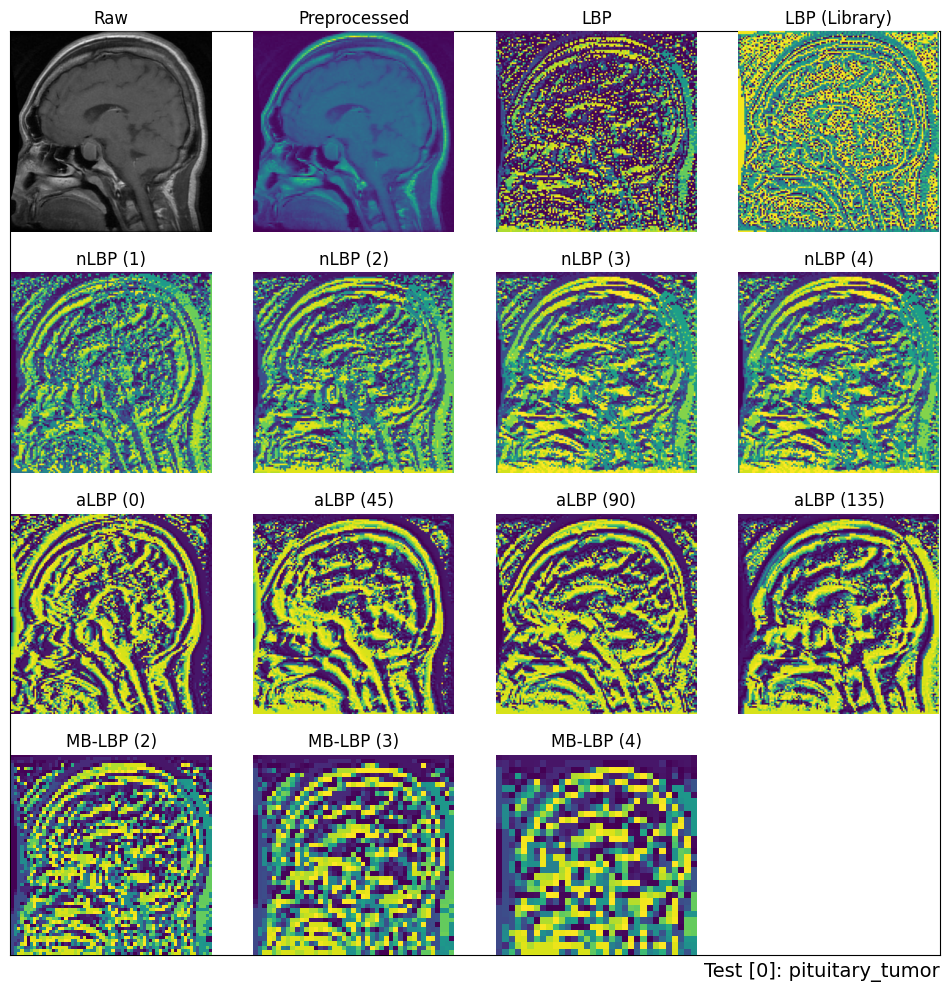

In [76]:
plt.figure(figsize=(12,12))
plt.xlabel(f"Test [{PRVW_IDX}]: {classes[y_test[PRVW_IDX]]}", fontsize=14, loc="right")
plt.yticks([])
plt.xticks([])

def get_image_preview(title, data, idx):
    plt.subplot(4, 4, idx)
    plt.axis("off")
    plt.title(f"{title}")
    plt.imshow(data[PRVW_IDX])

get_image_preview("Raw", X_test, 1)
get_image_preview("Preprocessed", X_test_prep, 2)
get_image_preview("LBP", X_test_lbp, 3)
get_image_preview("LBP (Library)", X_test_lbplib, 4)
get_image_preview("nLBP (1)", X_test_nlbp2, 5)
get_image_preview("nLBP (2)", X_test_nlbp3, 6)
get_image_preview("nLBP (3)", X_test_nlbp4, 7)
get_image_preview("nLBP (4)", X_test_nlbp4, 8)
get_image_preview("aLBP (0)", X_test_albp0, 9)
get_image_preview("aLBP (45)", X_test_albp45, 10)
get_image_preview("aLBP (90)", X_test_albp90, 11)
get_image_preview("aLBP (135)", X_test_albp135, 12)
get_image_preview("MB-LBP (2)", X_test_mblbp2, 13)
get_image_preview("MB-LBP (3)", X_test_mblbp3, 14)
get_image_preview("MB-LBP (4)", X_test_mblbp4, 15)
# get_image("SEMB-LBP (2)", X_test_semblbp2, 17)
# get_image("SEMB-LBP (3)", X_test_semblbp3, 18)
# get_image("SEMB-LBP (4)", X_test_semblbp4, 19)

plt.show()

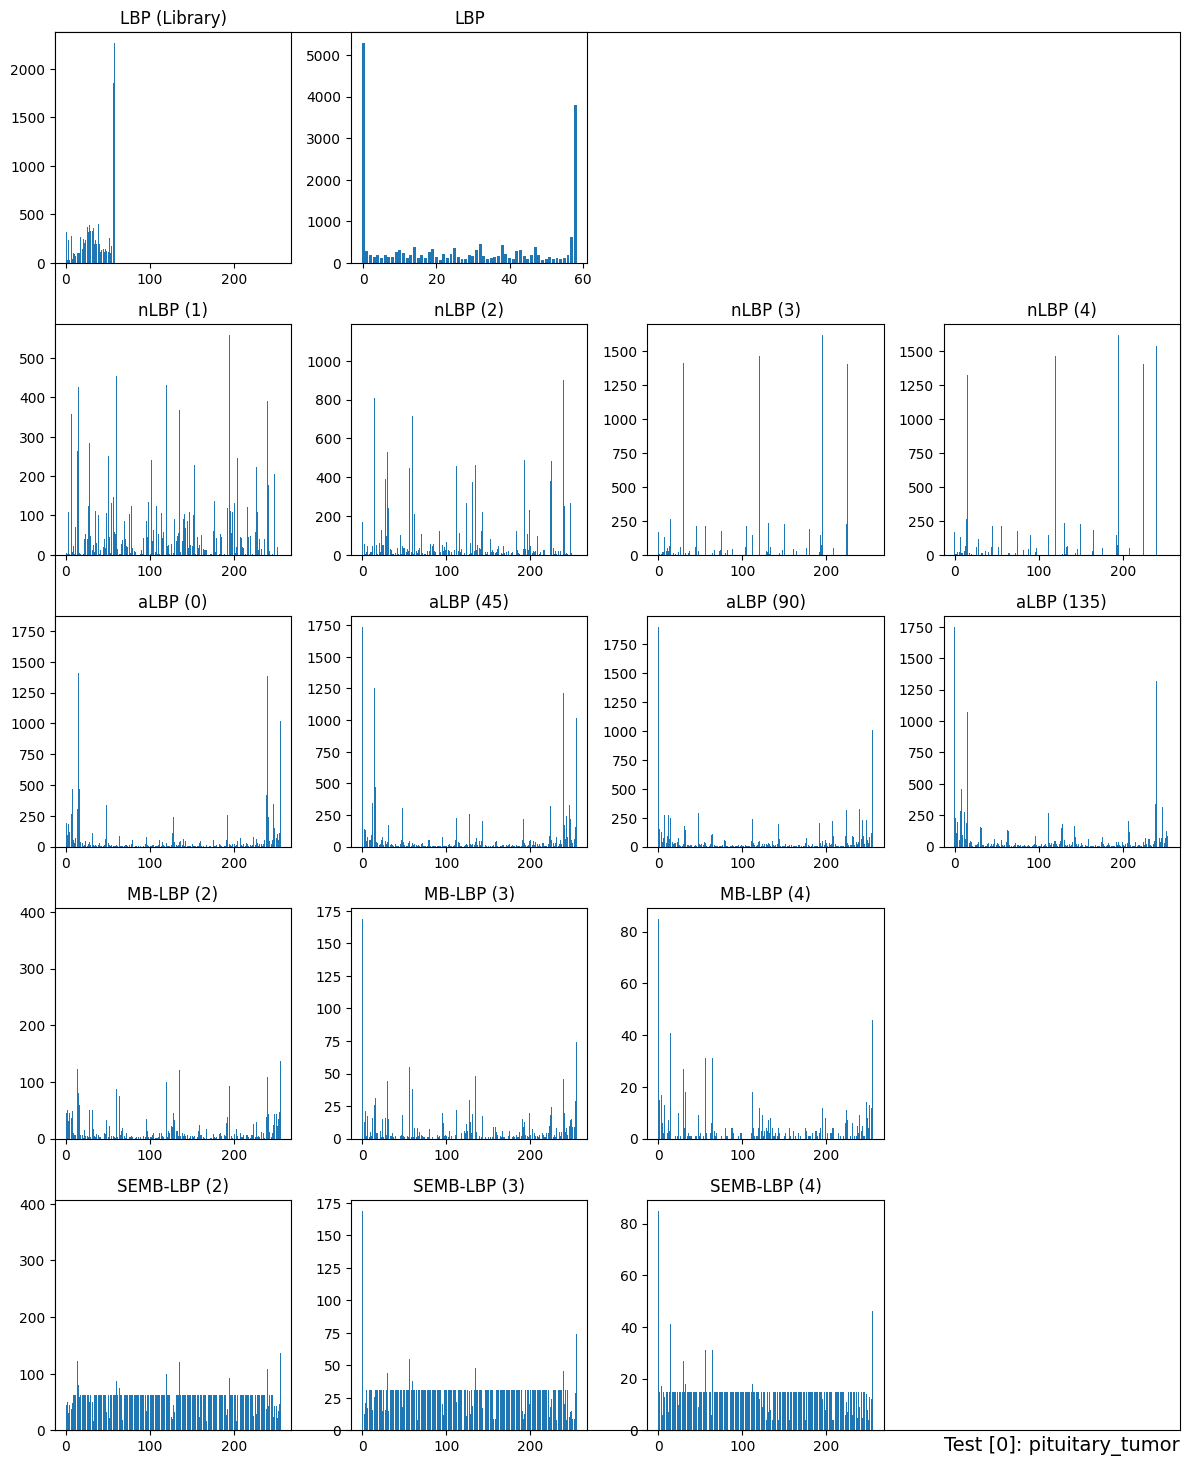

In [84]:
plt.figure(figsize=(12,15))
plt.xlabel(f"Test [{PRVW_IDX}]: {classes[y_test[PRVW_IDX]]}", fontsize=14, loc="right")
plt.yticks([])
plt.xticks([])

# get_histogram_preview("Raw", X_test, 1)
# get_histogram_preview("Preprocessed", X_test_prep, 2)
get_histogram_preview("LBP (Library)", X_test_lbplib_hist, 1)
get_histogram_preview("LBP", X_test_lbp_hist, 2)
get_histogram_preview("nLBP (1)", X_test_nlbp2_hist, 5)
get_histogram_preview("nLBP (2)", X_test_nlbp3_hist, 6)
get_histogram_preview("nLBP (3)", X_test_nlbp4_hist, 7)
get_histogram_preview("nLBP (4)", X_test_nlbp4_hist, 8)
get_histogram_preview("aLBP (0)", X_test_albp0_hist, 9)
get_histogram_preview("aLBP (45)", X_test_albp45_hist, 10)
get_histogram_preview("aLBP (90)", X_test_albp90_hist, 11)
get_histogram_preview("aLBP (135)", X_test_albp135_hist, 12)
get_histogram_preview("MB-LBP (2)", X_test_mblbp2_hist, 13)
get_histogram_preview("MB-LBP (3)", X_test_mblbp3_hist, 14)
get_histogram_preview("MB-LBP (4)", X_test_mblbp4_hist, 15)
get_histogram_preview("SEMB-LBP (2)", X_test_semblbp2_hist, 17)
get_histogram_preview("SEMB-LBP (3)", X_test_semblbp3_hist, 18)
get_histogram_preview("SEMB-LBP (4)", X_test_semblbp4_hist, 19)

plt.show()

#### Evaluation Process

--------------------------------- Best KNN | nlbp1 ---------------------------------


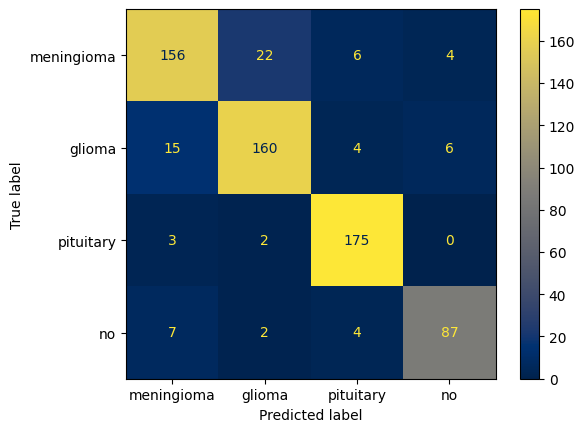

> Local Performance
Class		Accuracy		Precision		Recall			F1-Score
meningioma	0.9127105666156202  	0.861878453038674   	0.8297872340425532  	0.8455284552845529  
glioma    	0.9218989280245024  	0.8602150537634409  	0.8648648648648649  	0.8625336927223719  
pituitary 	0.9709035222052067  	0.9259259259259259  	0.9722222222222222  	0.948509485094851   
no        	0.9647779479326187  	0.8969072164948454  	0.87                	0.883248730964467   

> Global Performance
Accuracy (Micro) : 0.942572741194487
Accuracy (Macro) : 0.885145482388974
Precision        : 0.8862316623057216
Recall           : 0.8842185802824101
F1-Score         : 0.8849550910165607


In [91]:
knn_best_preds = knn_best["model"].predict(X_test_nlbp1_hist)
knn_best_eval = evaluate_model(knn_best_preds)
display_evaluation(f"Best KNN | {knn_best["method"]}", knn_best_eval)
# .94 .88

--------------------------------- Best Scaled KNN | lbp ---------------------------------


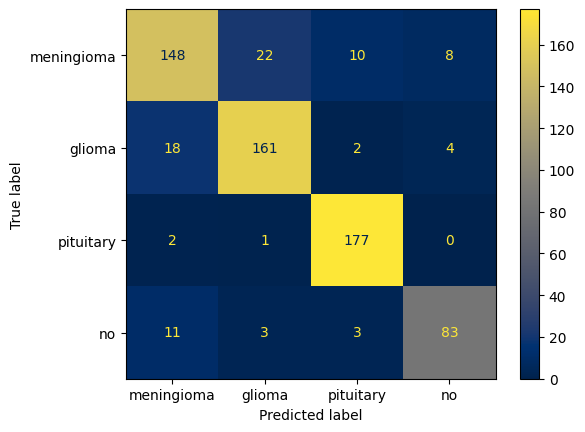

> Local Performance
Class		Accuracy		Precision		Recall			F1-Score
meningioma	0.891271056661562   	0.8268156424581006  	0.7872340425531915  	0.8065395095367848  
glioma    	0.9234303215926493  	0.8609625668449198  	0.8702702702702703  	0.8655913978494624  
pituitary 	0.9724349157733537  	0.921875            	0.9833333333333333  	0.9516129032258064  
no        	0.9555895865237366  	0.8736842105263158  	0.83                	0.8512820512820513  

> Global Performance
Accuracy (Micro) : 0.9356814701378254
Accuracy (Macro) : 0.8713629402756509
Precision        : 0.8708343549573341
Recall           : 0.8677094115391988
F1-Score         : 0.8687564654735263


In [104]:
knn_s_best_preds = knn_s_best["model"].predict(X_test_lbp_hist)
knn_s_best_eval = evaluate_model(knn_s_best_preds)
display_evaluation(f"Best Scaled KNN | {knn_s_best["method"]}", knn_s_best_eval)
# .93 .86

--------------------------------- Best DT | lbp ---------------------------------


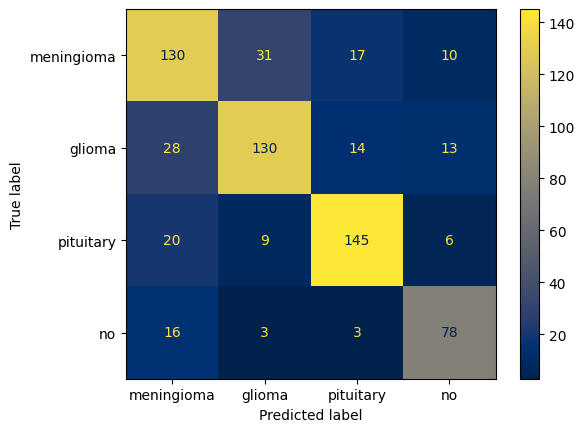

> Local Performance
Class		Accuracy		Precision		Recall			F1-Score
meningioma	0.8131699846860643  	0.6701030927835051  	0.6914893617021277  	0.6806282722513088  
glioma    	0.8499234303215927  	0.7514450867052023  	0.7027027027027027  	0.7262569832402234  
pituitary 	0.8943338437978561  	0.8100558659217877  	0.8055555555555556  	0.8077994428969361  
no        	0.9218989280245024  	0.7289719626168224  	0.78                	0.7536231884057971  

> Global Performance
Accuracy (Micro) : 0.8698315467075038
Accuracy (Macro) : 0.7396630934150077
Precision        : 0.7401440020068294
Recall           : 0.7449369049900965
F1-Score         : 0.7420769716985665


In [97]:
dt_best_preds = dt_best["model"].predict(X_test_lbp_hist)
dt_best_eval = evaluate_model(dt_best_preds)
display_evaluation(f"Best DT | {dt_best["method"]}", dt_best_eval)
# .86 .74

--------------------------------- Best Scaled DT | lbp ---------------------------------


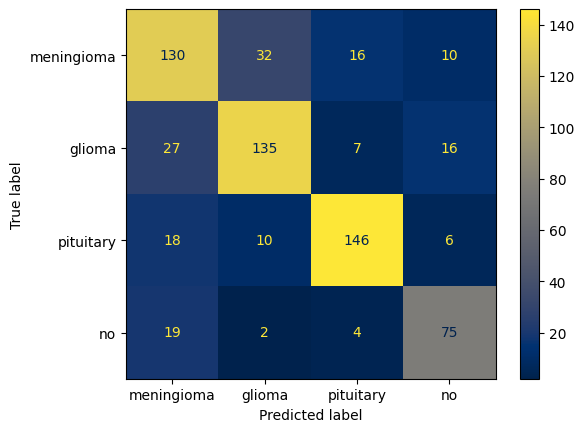

> Local Performance
Class		Accuracy		Precision		Recall			F1-Score
meningioma	0.8131699846860643  	0.6701030927835051  	0.6914893617021277  	0.6806282722513088  
glioma    	0.8560490045941807  	0.7541899441340782  	0.7297297297297297  	0.7417582417582417  
pituitary 	0.9065849923430321  	0.8439306358381503  	0.8111111111111111  	0.8271954674220964  
no        	0.9127105666156202  	0.7009345794392523  	0.75                	0.7246376811594203  

> Global Performance
Accuracy (Micro) : 0.8721286370597243
Accuracy (Macro) : 0.7442572741194488
Precision        : 0.7422895630487465
Recall           : 0.7455825506357421
F1-Score         : 0.7435549156477668


In [105]:
dt_s_best_preds = dt_s_best["model"].predict(X_test_lbp_hist)
dt_s_best_eval = evaluate_model(dt_s_best_preds)
display_evaluation(f"Best Scaled DT | {dt_s_best["method"]}", dt_s_best_eval)
# .87 .74

--------------------------------- Best RF | lbp ---------------------------------


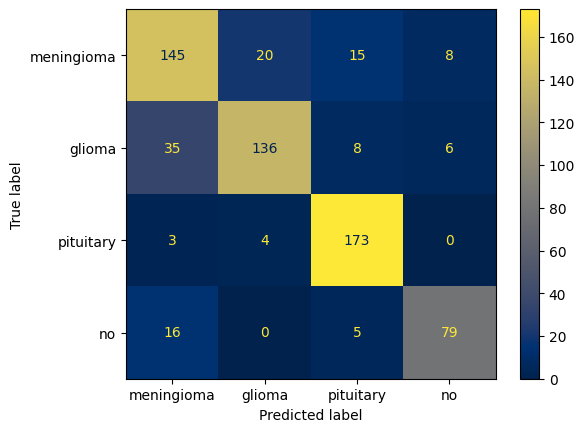

> Local Performance
Class		Accuracy		Precision		Recall			F1-Score
meningioma	0.8514548238897397  	0.7286432160804021  	0.7712765957446809  	0.7493540051679587  
glioma    	0.888208269525268   	0.85                	0.7351351351351352  	0.7884057971014493  
pituitary 	0.9464012251148545  	0.8606965174129353  	0.9611111111111111  	0.9081364829396326  
no        	0.9464012251148545  	0.8494623655913979  	0.79                	0.8186528497409327  

> Global Performance
Accuracy (Micro) : 0.9081163859111792
Accuracy (Macro) : 0.8162327718223583
Precision        : 0.8222005247711839
Recall           : 0.8143807104977319
F1-Score         : 0.8161372837374934


In [101]:
rf_best_preds = rf_best["model"].predict(X_test_lbp_hist)
rf_best_eval = evaluate_model(rf_best_preds)
display_evaluation(f"Best RF | {rf_best["method"]}", rf_best_eval)
# .90 .81

--------------------------------- Best Scaled RF | lbp ---------------------------------


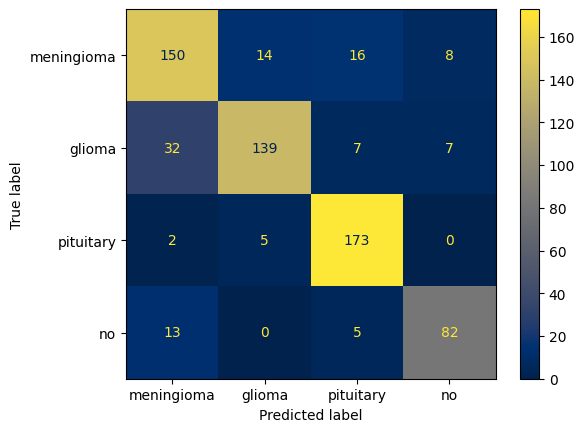

> Local Performance
Class		Accuracy		Precision		Recall			F1-Score
meningioma	0.8698315467075038  	0.7614213197969543  	0.7978723404255319  	0.779220779220779   
glioma    	0.900459418070444   	0.879746835443038   	0.7513513513513513  	0.8104956268221574  
pituitary 	0.9464012251148545  	0.8606965174129353  	0.9611111111111111  	0.9081364829396326  
no        	0.9494640122511485  	0.845360824742268   	0.82                	0.83248730964467    

> Global Performance
Accuracy (Micro) : 0.9165390505359877
Accuracy (Macro) : 0.8330781010719756
Precision        : 0.8368063743487989
Recall           : 0.8325837007219986
F1-Score         : 0.8325850496568097


In [106]:
rf_s_best_preds = rf_s_best["model"].predict(X_test_lbp_hist)
rf_s_best_eval = evaluate_model(rf_s_best_preds)
display_evaluation(f"Best Scaled RF | {rf_s_best["method"]}", rf_s_best_eval)
# .91 .83

--------------------------------- Best MNB | lbp ---------------------------------


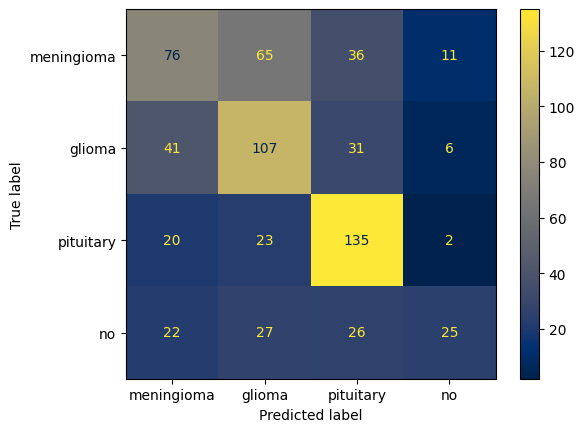

> Local Performance
Class		Accuracy		Precision		Recall			F1-Score
meningioma	0.7013782542113323  	0.4779874213836478  	0.40425531914893614 	0.4380403458213256  
glioma    	0.7044410413476263  	0.481981981981982   	0.5783783783783784  	0.5257985257985257  
pituitary 	0.7886676875957122  	0.5921052631578947  	0.75                	0.6617647058823529  
no        	0.8560490045941807  	0.5681818181818182  	0.25                	0.3472222222222222  

> Global Performance
Accuracy (Micro) : 0.7626339969372129
Accuracy (Macro) : 0.5252679938744257
Precision        : 0.5300641211763357
Recall           : 0.4956584243818286
F1-Score         : 0.4932064499311066


In [108]:
mnb_best_preds = mnb_best["model"].predict(X_test_lbp_hist)
mnb_best_eval = evaluate_model(mnb_best_preds)
display_evaluation(f"Best MNB | {mnb_best["method"]}", mnb_best_eval)

--------------------------------- Best GNB | lbp ---------------------------------


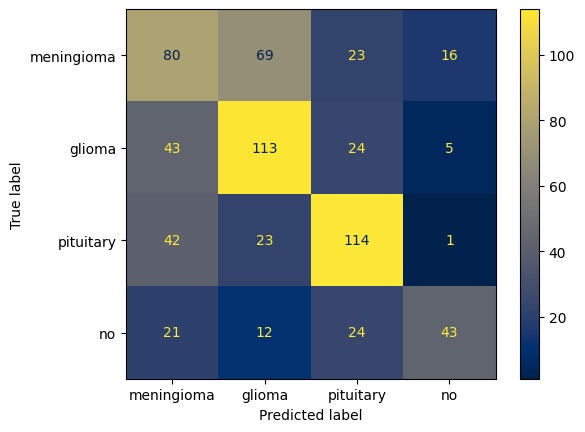

> Local Performance
Class		Accuracy		Precision		Recall			F1-Score
meningioma	0.6722817764165391  	0.43010752688172044 	0.425531914893617   	0.4278074866310161  
glioma    	0.7304747320061256  	0.5207373271889401  	0.6108108108108108  	0.5621890547263682  
pituitary 	0.7901990811638591  	0.6162162162162163  	0.6333333333333333  	0.6246575342465754  
no        	0.8790199081163859  	0.6615384615384615  	0.43                	0.5212121212121211  

> Global Performance
Accuracy (Micro) : 0.7679938744257273
Accuracy (Macro) : 0.5359877488514548
Precision        : 0.5571498829563345
Recall           : 0.5249190147594403
F1-Score         : 0.5339665492040202


In [ ]:
gnb_best_preds = gnb_best["model"].predict(X_test_lbp_hist)
gnb_best_eval = evaluate_model(gnb_best_preds)
display_evaluation(f"Best GNB | {gnb_best["method"]}", gnb_best_eval)
# .76 .53

--------------------------------- Best Scaled GNB | lbp ---------------------------------


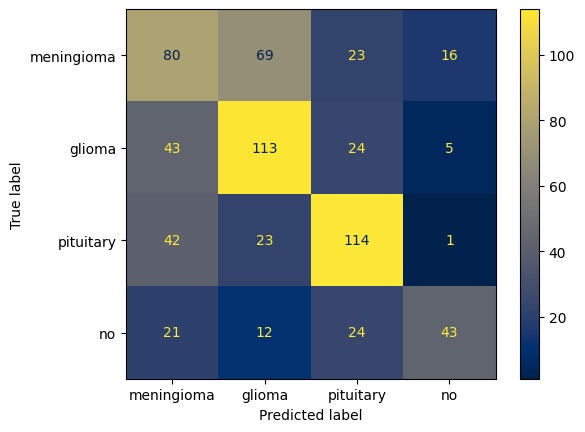

> Local Performance
Class		Accuracy		Precision		Recall			F1-Score
meningioma	0.6722817764165391  	0.43010752688172044 	0.425531914893617   	0.4278074866310161  
glioma    	0.7304747320061256  	0.5207373271889401  	0.6108108108108108  	0.5621890547263682  
pituitary 	0.7901990811638591  	0.6162162162162163  	0.6333333333333333  	0.6246575342465754  
no        	0.8790199081163859  	0.6615384615384615  	0.43                	0.5212121212121211  

> Global Performance
Accuracy (Micro) : 0.7679938744257273
Accuracy (Macro) : 0.5359877488514548
Precision        : 0.5571498829563345
Recall           : 0.5249190147594403
F1-Score         : 0.5339665492040202


In [ ]:
gnb_s_best_preds = gnb_s_best["model"].predict(X_test_lbp_hist)
gnb_s_best_eval = evaluate_model(gnb_s_best_preds)
display_evaluation(f"Best Scaled GNB | {gnb_s_best["method"]}", gnb_s_best_eval)
# .76 .53

--------------------------------- Best SVM | nlbp1 ---------------------------------


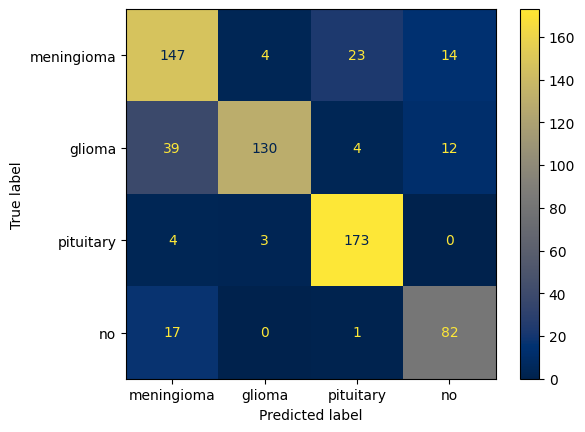

> Local Performance
Class		Accuracy		Precision		Recall			F1-Score
meningioma	0.8453292496171516  	0.7101449275362319  	0.7819148936170213  	0.7443037974683545  
glioma    	0.9050535987748851  	0.948905109489051   	0.7027027027027027  	0.8074534161490684  
pituitary 	0.9464012251148545  	0.8606965174129353  	0.9611111111111111  	0.9081364829396326  
no        	0.9326186830015314  	0.7592592592592593  	0.82                	0.7884615384615384  

> Global Performance
Accuracy (Micro) : 0.9073506891271057
Accuracy (Macro) : 0.8147013782542113
Precision        : 0.8197514534243695
Recall           : 0.8164321768577087
F1-Score         : 0.8120888087546485


In [115]:
svm_best_preds = svm_best["model"].predict(X_test_nlbp1_hist)
svm_best_eval = evaluate_model(svm_best_preds)
display_evaluation(f"Best SVM | {svm_best["method"]}", svm_best_eval)
# .90 .81

--------------------------------- Best Scaled SVM | lbp ---------------------------------


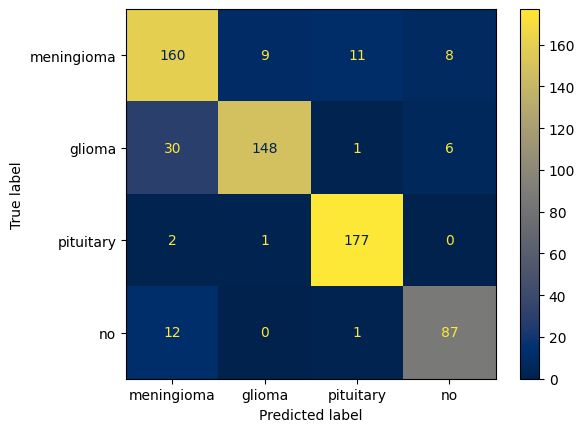

> Local Performance
Class		Accuracy		Precision		Recall			F1-Score
meningioma	0.889739663093415   	0.7843137254901961  	0.851063829787234   	0.8163265306122448  
glioma    	0.9280245022970903  	0.9367088607594937  	0.8                 	0.8629737609329446  
pituitary 	0.9754977029096478  	0.9315789473684211  	0.9833333333333333  	0.9567567567567566  
no        	0.9586523736600306  	0.8613861386138614  	0.87                	0.8656716417910448  

> Global Performance
Accuracy (Micro) : 0.9379785604900459
Accuracy (Macro) : 0.8759571209800919
Precision        : 0.878496918057993
Recall           : 0.8760992907801419
F1-Score         : 0.8754321725232477


In [116]:
svm_s_best_preds = svm_s_best["model"].predict(X_test_lbp_hist)
svm_s_best_eval = evaluate_model(svm_s_best_preds)
display_evaluation(f"Best Scaled SVM | {svm_s_best["method"]}", svm_s_best_eval)
# .93 .87

## Deep Learning

#### DL - Preprocessing

In [117]:
def preprocess_dl(images):
    preprocessed = []
    for img in images:
        # Resize image into same resolutions
        # 224x224
        img_resized = cv.resize(img, (CNN_IMAGE_SIZE, CNN_IMAGE_SIZE))

        # Convert image from BGR (default configuration of MRI image dataset) 
        # to RGB (preferred image channel for scikit-learn CNN model)
        img_rgb = cv.cvtColor(img_resized, cv.COLOR_BGR2RGB)

        # Normailze image pixel intensity values
        img_norm = img_rgb / 255

        preprocessed.append(img_norm)
    return preprocessed

In [118]:
# Preprocess dataset for deep learning using the same data as ML 
X_train_cnn = np.array(preprocess_dl(X_train))
y_train_cnn = np.array(y_train.copy())

X_test_cnn = np.array(preprocess_dl(X_test))
y_test_cnn = np.array(y_test.copy())

print("X_train_cnn\ty_train_cnn\t")
print(f"{len(X_train_cnn)}\t\t{len(y_train_cnn)}\n")
print("X_test_cnn\ty_test_cnn\t")
print(f"{len(X_test_cnn)}\t\t{len(y_test_cnn)}\t")

X_train_cnn	y_train_cnn	
2611		2611

X_test_cnn	y_test_cnn	
653		653	


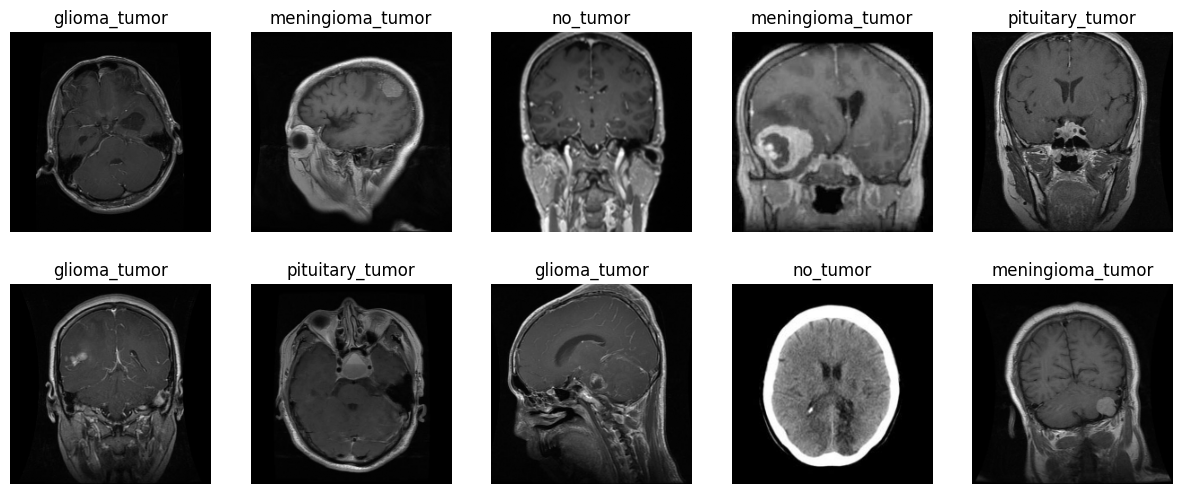

In [119]:
# Display training sample images
plt.figure(figsize=(15,6))
for i in range(1,11):
    plt.subplot(2,5,i)
    plt.axis("off")
    plt.title(classes[y_train_cnn[i]])
    plt.imshow(X_train_cnn[i])
plt.show()

### DL - Modelling

In [120]:
cnn_model = keras.Sequential([
    layers.Input(shape=(CNN_IMAGE_SIZE,CNN_IMAGE_SIZE,3)),

    layers.Conv2D(filters=32, kernel_size=(3,3), 
                  activation='relu', padding='same'),
    layers.MaxPool2D((2,2)),

    layers.Conv2D(filters=64, kernel_size=(3,3), 
                  activation='relu', padding='same'),
    layers.MaxPool2D((2,2)),

    layers.Flatten(),
    
    layers.Dense(units=128, activation='relu'),
    layers.Dropout(rate=0.4), # Overfit handling
    layers.Dense(units=4, activation='softmax')
])

cnn_model.summary()

E0000 00:00:1775121014.487874    5176 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1775121014.497196    5176 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 200704)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    25,690,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,710,148 (98.08 MB)

 Trainable params: 25,710,148 (98.08 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cnn_model.compile(
    optimizer=keras.optimizers.Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=[keras.metrics.sparse_categorical_accuracy]
)

start = time.perf_counter()
# Train and validate CNN model
cnn_history = cnn_model.fit(
    X_train_cnn,
    y_train_cnn,
    epochs=10,
    batch_size=64,
    validation_split=0.3,   
)
emd = time.perf_counter()
cnn_time = end - start

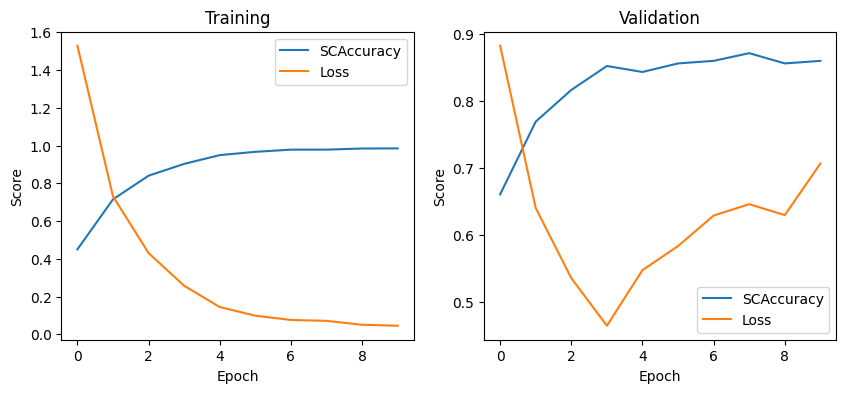

In [122]:
plt.figure(figsize=(10,4))

# Plot training performance score graph
plt.subplot(1,2,1)
plt.title("Training")
plt.plot(cnn_history.history["sparse_categorical_accuracy"])
plt.plot(cnn_history.history["loss"])
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend(["SCAccuracy", "Loss"])

# Plot validation performance score graph
plt.subplot(1,2,2)
plt.title("Validation")
plt.plot(cnn_history.history["val_sparse_categorical_accuracy"])
plt.plot(cnn_history.history["val_loss"])
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend(["SCAccuracy", "Loss"])

plt.show()

### DL - Evaluation

In [123]:
# Test CNN model performance with unseen test data
cnn_loss, cnn_accuracy = cnn_model.evaluate(
    X_test_cnn,
    y_test_cnn,
)

print("Accuracy >", cnn_accuracy)
print("Loss     >", cnn_loss)

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.7888 - sparse_categorical_accuracy: 0.8438
Accuracy > 0.8437978625297546
Loss     > 0.7888167500495911


## Explainable AI

#### XAI - LIME

In [ ]:
def svm_best_predict(images):
    features = []
    for img in images:
        img_resized = cv.resize(img, (IMAGE_SIZE, IMAGE_SIZE))
        img_gray = cv.cvtColor(img_resized, cv.COLOR_BGR2GRAY)
        img_nlbp2 = get_nlbp(img_gray, 2) # TODO: replace with the best performance LBP method
        img_hist = get_histogram(img_nlbp2)
        features.append(img_hist)
    return svm_best[1].predict(np.array(features))

In [ ]:
explainer = lime_image.LimeImageExplainer()

explanation = explainer.explain_instance(X[0], 
                                         svm_best_predict,
                                        #  top_labels=4,
                                        #  hide_color=0, 
                                         num_samples=100)

  9%|▉         | 9/100 [00:00<00:01, 80.76it/s]


NameError: name 'get_nlbp' is not defined

In [ ]:
from skimage.segmentation import mark_boundaries

label = explanation.top_labels[0]
print(classes[label], classes[y_test[100]])

temp, mask = explanation.get_image_and_mask(explanation.top_labels[0],
                                            positive_only=False,
                                            num_features=1,
                                            hide_rest=False)

plt.title(f"{classes[y_test[100]]} ({y_test[100]})")
plt.imshow(mark_boundaries(temp, mask))
plt.axis("off")
plt.show()

NameError: name 'explanation' is not defined

## TODO: Save Model

# System Usage Monitor

- ML (Feature Extractions)
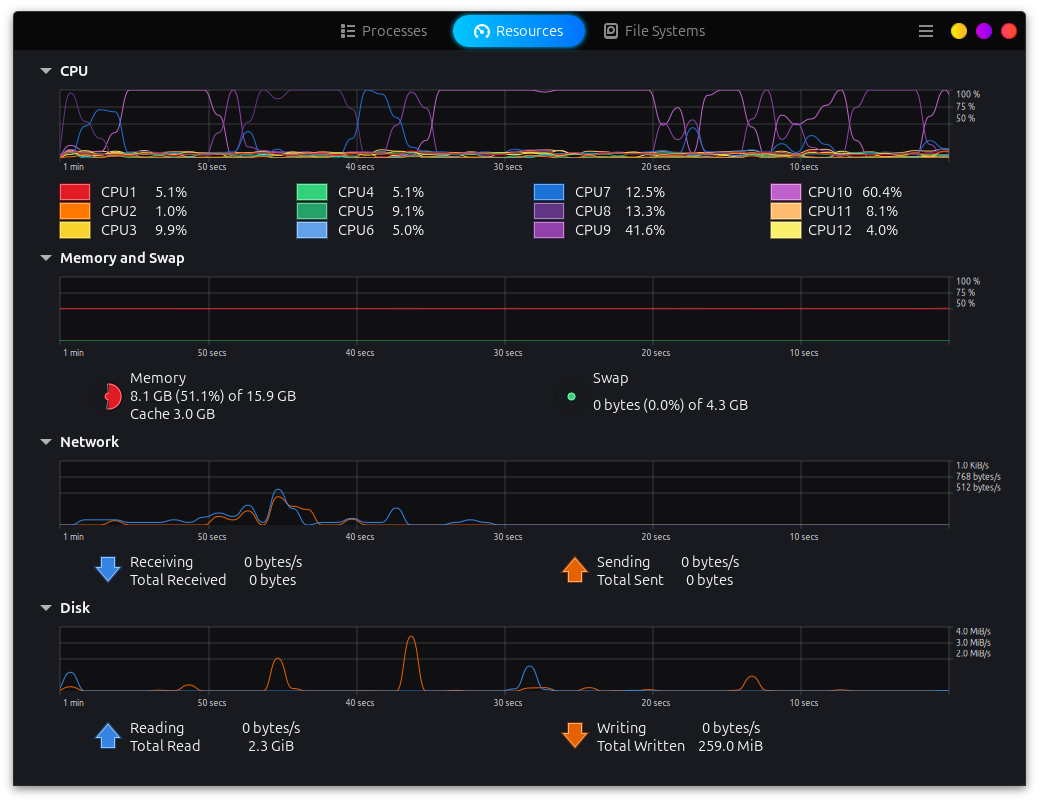

- SVM (Modelling)
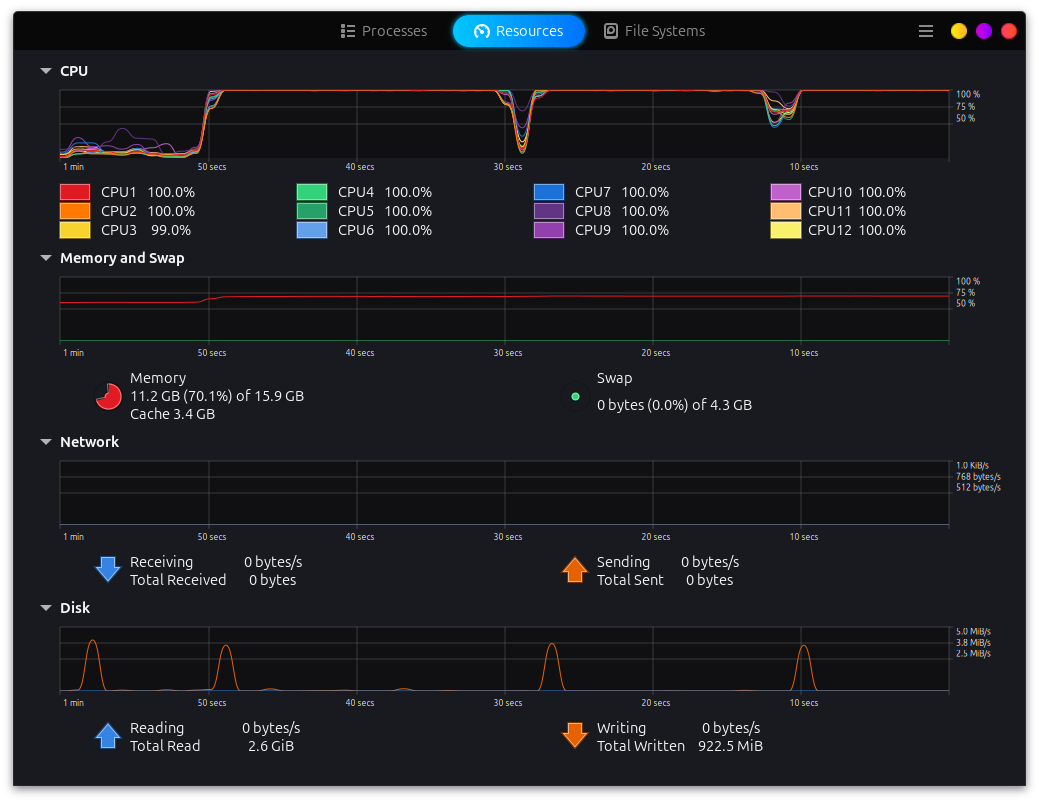